In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import pandas as pd
import torch
from torch.utils.data import DataLoader, Dataset, random_split
import numpy as np
import matplotlib.pyplot as plt
from constants import CALCEDatasetConstants, ModelOutputConstants, NASADatasetConstants
from preprocessing_functions import generate_sliding_window_data
from models import TCN_GRU_DNN_Model, BiLSTM_Attention, abc_algorithm, BiGRUModel, CNN_DBLSTM_Model, CNN_ASTLSTM
from models.train import train_model
from models.evaluate import evaluate_model, plot_predictions
from models.save_load import save_model, load_model
import pathlib

In [3]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'

In [4]:
TRAIN_RATIO = 0.8
VAL_RATIO = 1 - TRAIN_RATIO

class CustomDataset(Dataset):
    def __init__(self, x, y):
        self.x = x
        self.y = y

    def __len__(self):
        return self.y.shape[0]

    def __getitem__(self, idx):
        return self.x[idx, :], self.y[idx]

# CALCE Dataset

## Loading the Data

In [5]:
PROCESSED_BATTERY_PATHS = [CALCEDatasetConstants.BATTERY_PROCESSED_PATH.value / (battery_name+'.csv') for battery_name in CALCEDatasetConstants.BATTERY_NAMES.value]
PROCESSED_BATTERY_PATHS

[WindowsPath('C:/Users/shubham mate/Desktop/Programming/Python/Battery RUL Project/data/CALCE/Preprocessed/CS2_35.csv'),
 WindowsPath('C:/Users/shubham mate/Desktop/Programming/Python/Battery RUL Project/data/CALCE/Preprocessed/CS2_36.csv'),
 WindowsPath('C:/Users/shubham mate/Desktop/Programming/Python/Battery RUL Project/data/CALCE/Preprocessed/CS2_37.csv'),
 WindowsPath('C:/Users/shubham mate/Desktop/Programming/Python/Battery RUL Project/data/CALCE/Preprocessed/CS2_38.csv')]

In [6]:
dfs = {CALCEDatasetConstants.BATTERY_NUMBERS.value[i]: \
       pd.read_csv(PROCESSED_BATTERY_PATHS[i]).drop(['Unnamed: 0'], axis=1) for i in range(len(CALCEDatasetConstants.BATTERY_NUMBERS.value))}
dfs

{35:      Cycle_Index  Discharge_Capacity(Ah)
 0              1                1.123221
 1              2                1.111035
 2              3                1.106058
 3              4                1.102627
 4              5                1.098143
 ..           ...                     ...
 757          758                0.332357
 758          759                0.328566
 759          760                0.325232
 760          761                0.322707
 761          762                0.319955
 
 [762 rows x 2 columns],
 36:      Cycle_Index  Discharge_Capacity(Ah)
 0              1                1.134613
 1              2                1.124949
 2              3                1.121679
 3              4                1.119217
 4              5                1.115648
 ..           ...                     ...
 768          769                0.173019
 769          770                0.169924
 770          771                0.168700
 771          772                0.168793

# Visualizing the data along with train test split

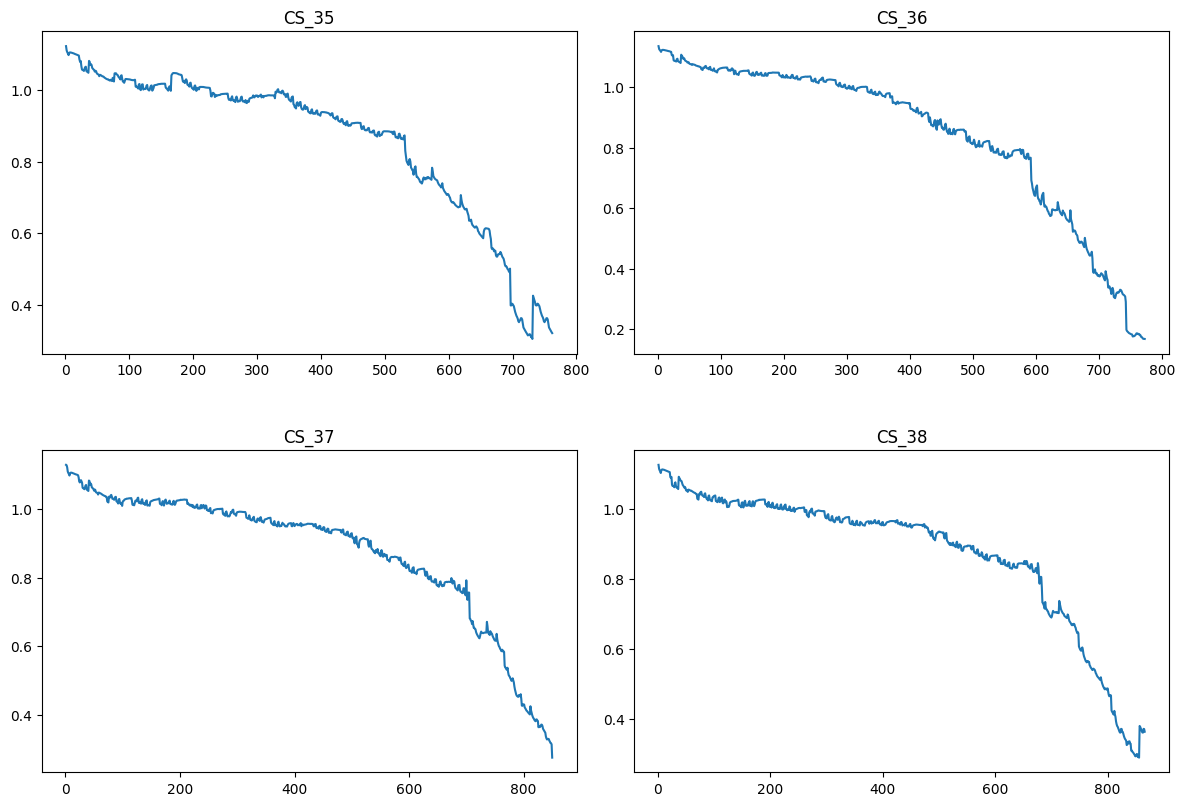

In [7]:
fig, ax = plt.subplots(nrows=int(len(dfs)/2), ncols=2, figsize=(12, 8))
fig.tight_layout()
plt.subplots_adjust(hspace=0.3)

for i, (battery_number, df) in enumerate(dfs.items()):
    ax[int(i/2), i%2].plot(df['Cycle_Index'], df['Discharge_Capacity(Ah)'])
    ax[int(i/2), i%2].set_title(f'CS_{battery_number}')

plt.show()

In [9]:
# Create a list containing test and training battery numbers for each case
test_and_trains = []

for battery_name in CALCEDatasetConstants.BATTERY_NUMBERS.value:
    excluded_list = [x for x in CALCEDatasetConstants.BATTERY_NUMBERS.value if x != battery_name]
    test_and_trains.append((battery_name, excluded_list))

test_and_trains

[(35, [36, 37, 38]), (36, [35, 37, 38]), (37, [35, 36, 38]), (38, [35, 36, 37])]


In [8]:
TRAINING_BATTERIES = CALCEDatasetConstants.BATTERY_NUMBERS.value[:3]
TEST_BATTERY = CALCEDatasetConstants.BATTERY_NUMBERS.value[3]

In [9]:
x, y = generate_sliding_window_data(dfs[TRAINING_BATTERIES[0]]['Discharge_Capacity(Ah)'])
x.shape, y.shape

((752, 10), (752,))

In [10]:
x.shape, y.shape

((752, 10), (752,))

In [10]:
CALCE_train_dataloaders = []
CALCE_val_dataloaders = []
CALCE_test_dataloaders = []

for test_battery, training_batteries in test_and_trains:
    
    trainX = []
    trainY = []
    
    for battery in training_batteries:
        x, y = generate_sliding_window_data(dfs[battery]['Discharge_Capacity(Ah)'])
        trainX.extend(x)
        trainY.extend(y)
    
    trainX, trainY = np.array(trainX), np.array(trainY)
    
    testX, testY = generate_sliding_window_data(dfs[test_battery]['Discharge_Capacity(Ah)'])
    testX, testY = np.array(testX), np.array(testY)
    
    train_dataset = CustomDataset(trainX, trainY)
    
    dataset_size = len(train_dataset)
    train_size = int(dataset_size * TRAIN_RATIO)
    val_size = dataset_size - train_size
    train_subset, val_subset = random_split(train_dataset, [train_size, val_size])
    
    train_dataloader = DataLoader(train_subset, batch_size=32, shuffle=True)
    val_dataloader = DataLoader(val_subset, batch_size=32, shuffle=True)
    
    test_dataset = CustomDataset(testX, testY)
    test_dataloader = DataLoader(test_dataset, batch_size=32, shuffle=True)

    CALCE_train_dataloaders.append(train_dataloader)
    CALCE_val_dataloaders.append(val_dataloader)
    CALCE_test_dataloaders.append(test_dataloader)

In [12]:
CALCE_train_dataloaders, CALCE_val_dataloaders, CALCE_test_dataloaders

([<torch.utils.data.dataloader.DataLoader at 0x115e6b990d0>,
  <torch.utils.data.dataloader.DataLoader at 0x115e6e5c3e0>])

In [15]:
MAX = 1.1
MIN = 0.0
DIFF = MAX - MIN

## TCN-GRU-DNN Model

Epoch 1: Validation loss improved to 0.6354850679636002. Model saved!
Epoch 1/50, Train Loss: 0.7498173088796677, Val Loss: 0.6354850679636002
Epoch 2: Validation loss improved to 0.046905015129595995. Model saved!
Epoch 2/50, Train Loss: 0.2573933654855336, Val Loss: 0.046905015129595995
Epoch 3: Validation loss improved to 0.03588585206307471. Model saved!
Epoch 3/50, Train Loss: 0.03902423808411244, Val Loss: 0.03588585206307471
Epoch 4: Validation loss improved to 0.03586035978514701. Model saved!
Epoch 4/50, Train Loss: 0.03772084359380026, Val Loss: 0.03586035978514701
Epoch 5: No improvement. (1/10)
Epoch 5/50, Train Loss: 0.037143152447477464, Val Loss: 0.03658086236100644
Epoch 6: Validation loss improved to 0.03348585683852434. Model saved!
Epoch 6/50, Train Loss: 0.03582658561607523, Val Loss: 0.03348585683852434
Epoch 7: Validation loss improved to 0.01395496673649177. Model saved!
Epoch 7/50, Train Loss: 0.028975995257496834, Val Loss: 0.01395496673649177
Epoch 8: Validati

C:\Users\shubham mate\AppData\Local\Temp\ipykernel_18176\3463446809.py:25: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model_1.load_state_dict(torch.load(ModelOutputConsta

RMSE: 0.015529180040344827
MAE: 0.009582010038355564


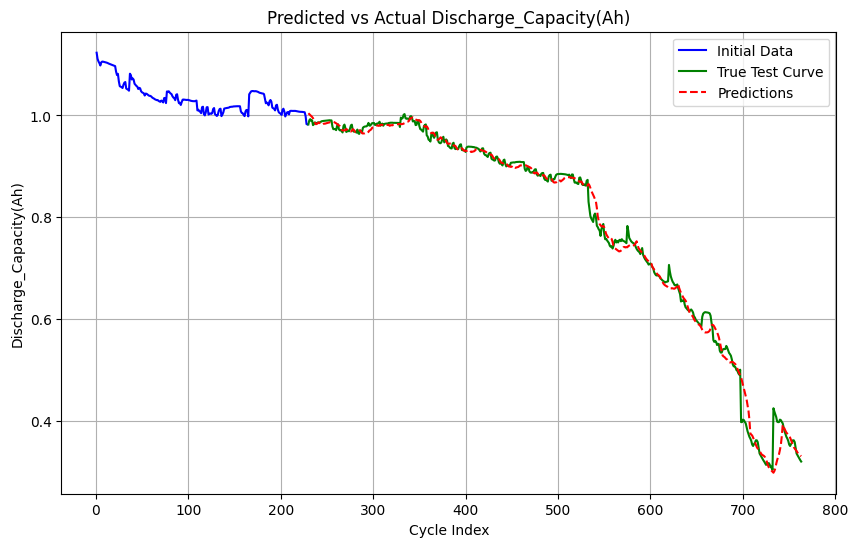

Epoch 1: Validation loss improved to 0.7602143920958042. Model saved!
Epoch 1/50, Train Loss: 0.8780922322503982, Val Loss: 0.7602143920958042
Epoch 2: Validation loss improved to 0.03784094378352165. Model saved!
Epoch 2/50, Train Loss: 0.32255246442171837, Val Loss: 0.03784094378352165
Epoch 3: Validation loss improved to 0.03403732005972415. Model saved!
Epoch 3/50, Train Loss: 0.031209113256585215, Val Loss: 0.03403732005972415
Epoch 4: Validation loss improved to 0.03267387539381161. Model saved!
Epoch 4/50, Train Loss: 0.030198260886414398, Val Loss: 0.03267387539381161
Epoch 5: Validation loss improved to 0.03204848722089082. Model saved!
Epoch 5/50, Train Loss: 0.029015238712271376, Val Loss: 0.03204848722089082
Epoch 6: Validation loss improved to 0.02732975225080736. Model saved!
Epoch 6/50, Train Loss: 0.026939340739420826, Val Loss: 0.02732975225080736
Epoch 7: Validation loss improved to 0.010553875123150647. Model saved!
Epoch 7/50, Train Loss: 0.02050466422412184, Val Lo

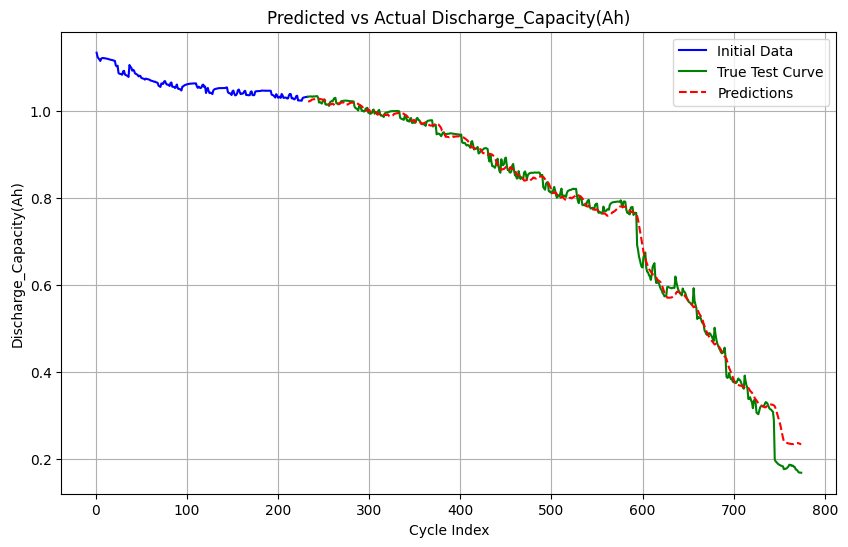

Epoch 1: Validation loss improved to 0.2134207993745804. Model saved!
Epoch 1/50, Train Loss: 0.2726651800175508, Val Loss: 0.2134207993745804
Epoch 2: Validation loss improved to 0.04394177968303362. Model saved!
Epoch 2/50, Train Loss: 0.1106532033222417, Val Loss: 0.04394177968303362
Epoch 3: Validation loss improved to 0.04060385090609391. Model saved!
Epoch 3/50, Train Loss: 0.03818194155270855, Val Loss: 0.04060385090609391
Epoch 4: Validation loss improved to 0.033315272505084675. Model saved!
Epoch 4/50, Train Loss: 0.03485759745041529, Val Loss: 0.033315272505084675
Epoch 5: Validation loss improved to 0.003628520256218811. Model saved!
Epoch 5/50, Train Loss: 0.01924152517846475, Val Loss: 0.003628520256218811
Epoch 6: Validation loss improved to 0.0011781932786107062. Model saved!
Epoch 6/50, Train Loss: 0.001889479040983133, Val Loss: 0.0011781932786107062
Epoch 7: Validation loss improved to 0.0006715922742538775. Model saved!
Epoch 7/50, Train Loss: 0.001151462594862096, 

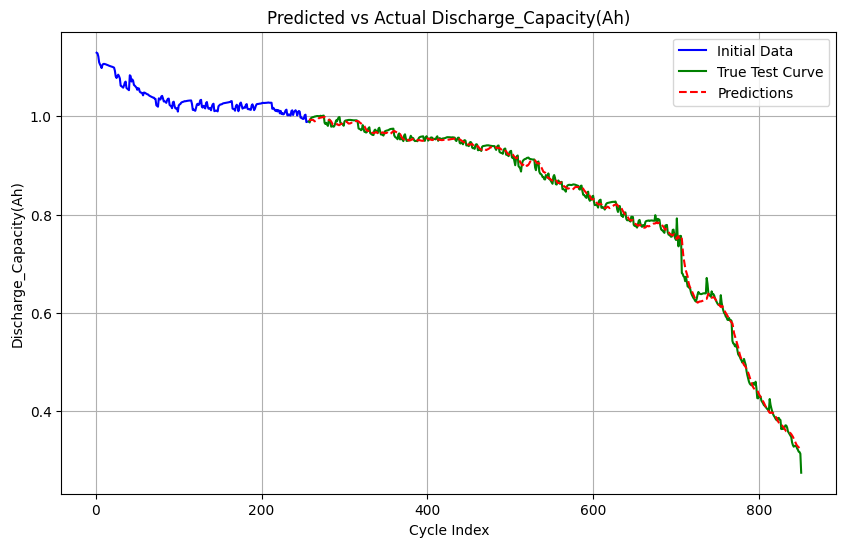

Epoch 1: Validation loss improved to 1.0188987612724305. Model saved!
Epoch 1/50, Train Loss: 1.0490366291191617, Val Loss: 1.0188987612724305
Epoch 2: Validation loss improved to 0.3317695160706838. Model saved!
Epoch 2/50, Train Loss: 0.6867880068593106, Val Loss: 0.3317695160706838
Epoch 3: Validation loss improved to 0.05054393857717514. Model saved!
Epoch 3/50, Train Loss: 0.1522260844328646, Val Loss: 0.05054393857717514
Epoch 4: Validation loss improved to 0.034664611270030336. Model saved!
Epoch 4/50, Train Loss: 0.04286032236354836, Val Loss: 0.034664611270030336
Epoch 5: Validation loss improved to 0.033376270656784376. Model saved!
Epoch 5/50, Train Loss: 0.039149986327452174, Val Loss: 0.033376270656784376
Epoch 6: Validation loss improved to 0.03035019040107727. Model saved!
Epoch 6/50, Train Loss: 0.036788546622304595, Val Loss: 0.03035019040107727
Epoch 7: Validation loss improved to 0.013615622868140538. Model saved!
Epoch 7/50, Train Loss: 0.02723782844210075, Val Loss

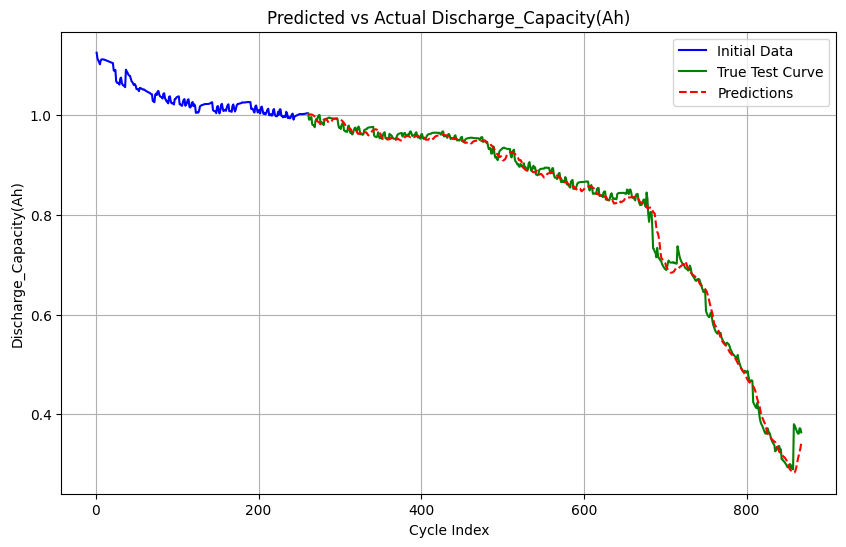

In [22]:

for i in range(4):
    model_1 = TCN_GRU_DNN_Model().to(device)
    optimizer = torch.optim.Adam(model_1.parameters(), lr=1e-4)
    criterion = torch.nn.MSELoss()
    EPOCHS = 50

    # Training
    train_model(
        model=model_1,
        train_dataloader=CALCE_train_dataloaders[i],
        val_dataloader = CALCE_val_dataloaders[i],
        optimizer=optimizer,
        criterion=criterion,
        device=device,
        min_val=MIN,
        diff_val=DIFF,
        epochs=EPOCHS,
        unsqueeze_dim=1,
        log_interval=1,
        patience=10,
        save_path=ModelOutputConstants.CALCE_OUTPUT_PATH.value / f'tcn_gru_dnn_{test_and_trains[i][0]}.pth'
    )

    # Evaluation
    model_1.load_state_dict(torch.load(ModelOutputConstants.CALCE_OUTPUT_PATH.value / f'tcn_gru_dnn_{test_and_trains[i][0]}.pth'))
    model_1.to(device)
    
    metrics = evaluate_model(model_1, CALCE_test_dataloaders[i], device, MIN, DIFF, 1)
    print(f'RMSE: {metrics['RMSE']}\nMAE: {metrics['MAE']}')

    # Plotting Curve
    plot_predictions(model_1, dfs, test_and_trains[i][0], generate_sliding_window_data, MIN, DIFF, device, 'Discharge_Capacity(Ah)', 1, 30)

In [18]:
metrics = evaluate_model(model_1, test_dataloader, device, MIN, DIFF, 1)
print(f'RMSE: {metrics['RMSE']}\nMAE: {metrics['MAE']}')

RMSE: 0.009994705719651886
MAE: 0.007432813782279737


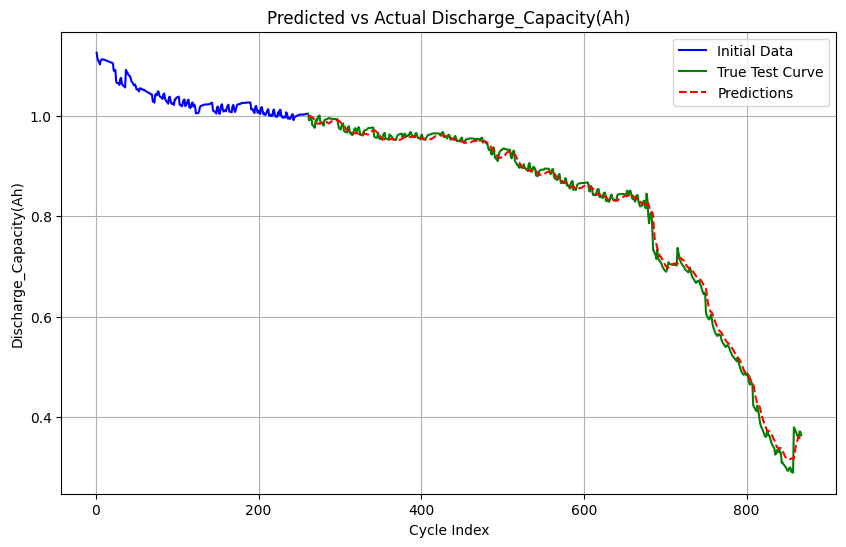

In [19]:
plot_predictions(model_1, dfs, TEST_BATTERY, generate_sliding_window_data, MIN, DIFF, device, 'Discharge_Capacity(Ah)', 1, 30)

## BiLSTM Attention Model

Epoch 1: Validation loss improved to 0.004257215216057375. Model saved!
Epoch 1/25, Train Loss: 0.07404674521286882, Val Loss: 0.004257215216057375
Epoch 2: Validation loss improved to 0.0001221759505369846. Model saved!
Epoch 2/25, Train Loss: 0.0011416584397774122, Val Loss: 0.0001221759505369846
Epoch 3: Validation loss improved to 0.00011862507244586595. Model saved!
Epoch 3/25, Train Loss: 0.00013022868288023728, Val Loss: 0.00011862507244586595
Epoch 4: No improvement. (1/5)
Epoch 4/25, Train Loss: 0.00013649096247043475, Val Loss: 0.0001665393247094471
Epoch 5: No improvement. (2/5)
Epoch 5/25, Train Loss: 0.00013923606333734033, Val Loss: 0.0001416563245584257
Epoch 6: Validation loss improved to 9.791591378416342e-05. Model saved!
Epoch 6/25, Train Loss: 0.00012913244685360922, Val Loss: 9.791591378416342e-05
Epoch 7: No improvement. (1/5)
Epoch 7/25, Train Loss: 0.0001254327990834774, Val Loss: 0.00013535379230233957
Epoch 8: No improvement. (2/5)
Epoch 8/25, Train Loss: 0.00

C:\Users\shubham mate\AppData\Local\Temp\ipykernel_18176\3914070405.py:23: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model_2.load_state_dict(torch.load(ModelOutputConsta

RMSE: 0.012193821934212432
MAE: 0.007237237937589909


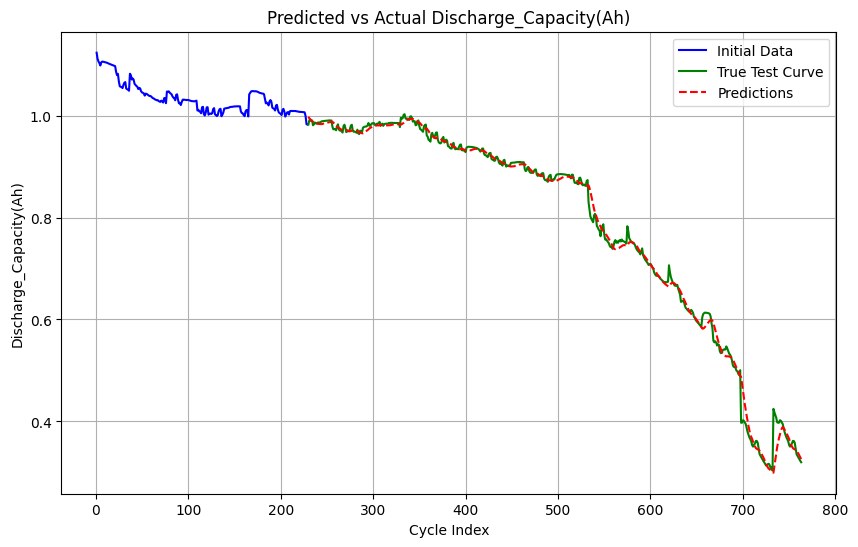

Epoch 1: Validation loss improved to 0.003907375292328652. Model saved!
Epoch 1/25, Train Loss: 0.06622125433322283, Val Loss: 0.003907375292328652
Epoch 2: Validation loss improved to 0.00019051369258704653. Model saved!
Epoch 2/25, Train Loss: 0.0007581760263776466, Val Loss: 0.00019051369258704653
Epoch 3: Validation loss improved to 0.00014907646459505486. Model saved!
Epoch 3/25, Train Loss: 0.00011409236239776345, Val Loss: 0.00014907646459505486
Epoch 4: No improvement. (1/5)
Epoch 4/25, Train Loss: 0.0001125714859353461, Val Loss: 0.000206672568765498
Epoch 5: No improvement. (2/5)
Epoch 5/25, Train Loss: 0.00012231292889590542, Val Loss: 0.00019005739704880398
Epoch 6: No improvement. (3/5)
Epoch 6/25, Train Loss: 0.00011871041985408914, Val Loss: 0.0001568756272263272
Epoch 7: No improvement. (4/5)
Epoch 7/25, Train Loss: 0.00011548146827525699, Val Loss: 0.00020295612193876877
Epoch 8: Validation loss improved to 0.00013475983985244966. Model saved!
Epoch 8/25, Train Loss: 0

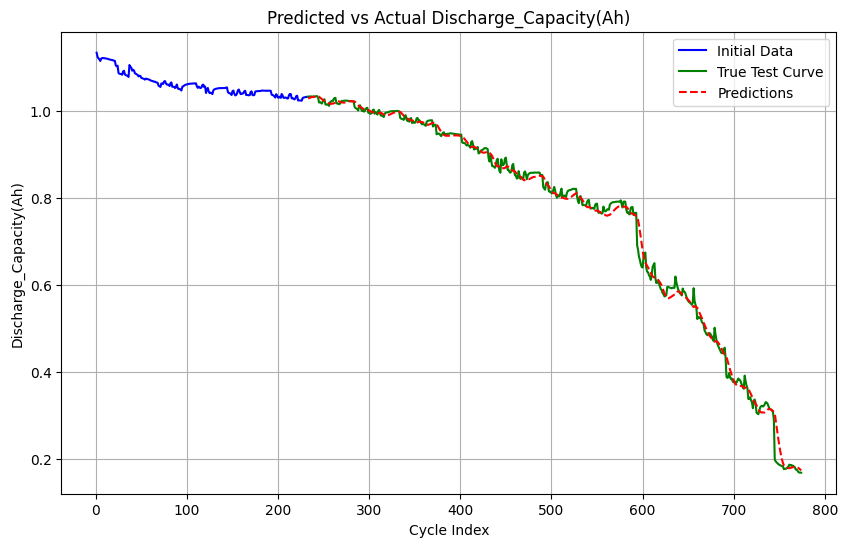

Epoch 1: Validation loss improved to 0.003914606322844823. Model saved!
Epoch 1/25, Train Loss: 0.07778941071592271, Val Loss: 0.003914606322844823
Epoch 2: Validation loss improved to 0.00021138671290827916. Model saved!
Epoch 2/25, Train Loss: 0.0009305274511765067, Val Loss: 0.00021138671290827916
Epoch 3: Validation loss improved to 0.00018898638906345394. Model saved!
Epoch 3/25, Train Loss: 0.00015112763721845113, Val Loss: 0.00018898638906345394
Epoch 4: No improvement. (1/5)
Epoch 4/25, Train Loss: 0.00014014280938378458, Val Loss: 0.00019616099598351866
Epoch 5: No improvement. (2/5)
Epoch 5/25, Train Loss: 0.0001381474767185864, Val Loss: 0.00019827788880017277
Epoch 6: No improvement. (3/5)
Epoch 6/25, Train Loss: 0.00014144732085696887, Val Loss: 0.0002628201560582966
Epoch 7: Validation loss improved to 0.000181121489489063. Model saved!
Epoch 7/25, Train Loss: 0.0001450657158784452, Val Loss: 0.000181121489489063
Epoch 8: Validation loss improved to 0.00017424237691254045

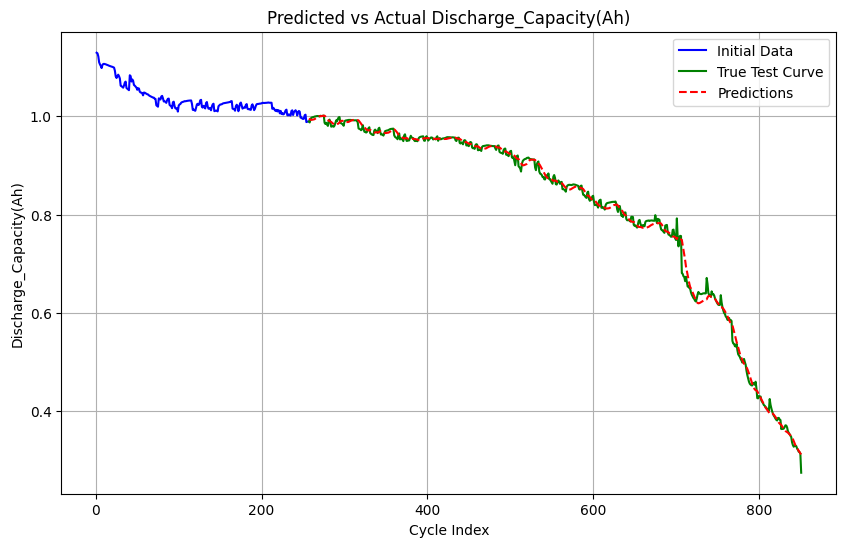

Epoch 1: Validation loss improved to 0.005171162883440653. Model saved!
Epoch 1/25, Train Loss: 0.059993269348169787, Val Loss: 0.005171162883440653
Epoch 2: Validation loss improved to 0.00013262117863632739. Model saved!
Epoch 2/25, Train Loss: 0.0012890955233962227, Val Loss: 0.00013262117863632739
Epoch 3: Validation loss improved to 0.00012129756214562804. Model saved!
Epoch 3/25, Train Loss: 0.0001526724619167399, Val Loss: 0.00012129756214562804
Epoch 4: Validation loss improved to 0.00010741960929105214. Model saved!
Epoch 4/25, Train Loss: 0.00014066267261622962, Val Loss: 0.00010741960929105214
Epoch 5: No improvement. (1/5)
Epoch 5/25, Train Loss: 0.00014244623988338004, Val Loss: 0.00010900835744299305
Epoch 6: No improvement. (2/5)
Epoch 6/25, Train Loss: 0.00015016671355717057, Val Loss: 0.00012768632198761526
Epoch 7: Validation loss improved to 0.00010380143588311815. Model saved!
Epoch 7/25, Train Loss: 0.00014539350722462602, Val Loss: 0.00010380143588311815
Epoch 8: 

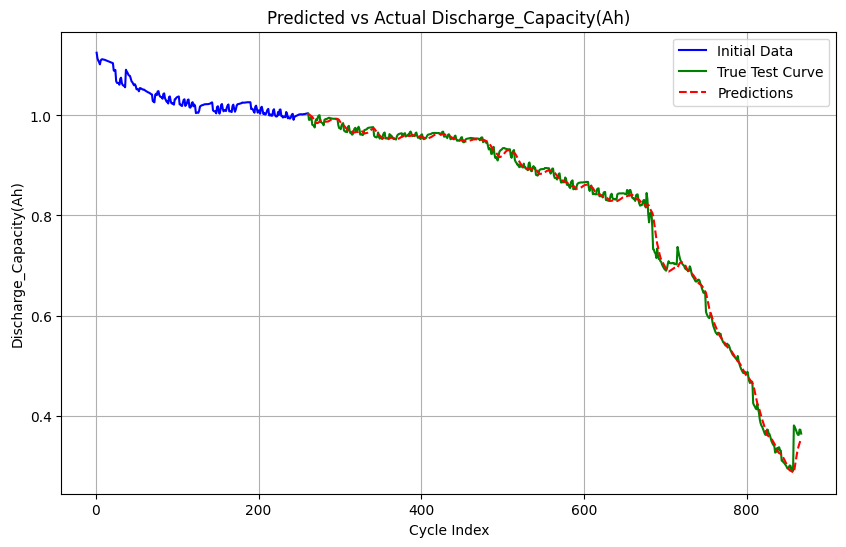

In [24]:

for i in range(4):
    model_2 = BiLSTM_Attention(128).to(device)
    optimizer = torch.optim.Adam(model_2.parameters(), lr=1e-3)
    criterion = torch.nn.MSELoss()
    EPOCHS = 25
    
    train_model(
        model=model_2,
        train_dataloader=CALCE_train_dataloaders[i],
        val_dataloader=CALCE_val_dataloaders[i],
        optimizer=optimizer,
        criterion=criterion,
        device=device,
        min_val=MIN,
        diff_val=DIFF,
        epochs=EPOCHS,
        unsqueeze_dim=-1,
        log_interval=1,
        patience=5,
        save_path=ModelOutputConstants.CALCE_OUTPUT_PATH.value / f'attn_bilstm{test_and_trains[i][0]}.pth'
    )
    
    model_2.load_state_dict(torch.load(ModelOutputConstants.CALCE_OUTPUT_PATH.value / f'attn_bilstm{test_and_trains[i][0]}.pth'))
    model_2.to(device)
    
    metrics = evaluate_model(model_2, CALCE_test_dataloaders[i], device, MIN, DIFF, -1)
    print(f'RMSE: {metrics['RMSE']}\nMAE: {metrics['MAE']}')

    plot_predictions(model_2, dfs, test_and_trains[i][0], generate_sliding_window_data, MIN, DIFF, device, 'Discharge_Capacity(Ah)', -1, 30)

In [44]:
metrics = evaluate_model(model_2, test_dataloader, device, MIN, DIFF, -1)
print(f'RMSE: {metrics['RMSE']}\nMAE: {metrics['MAE']}')

RMSE: 0.005601538985946446
MAE: 0.0037250833707713634


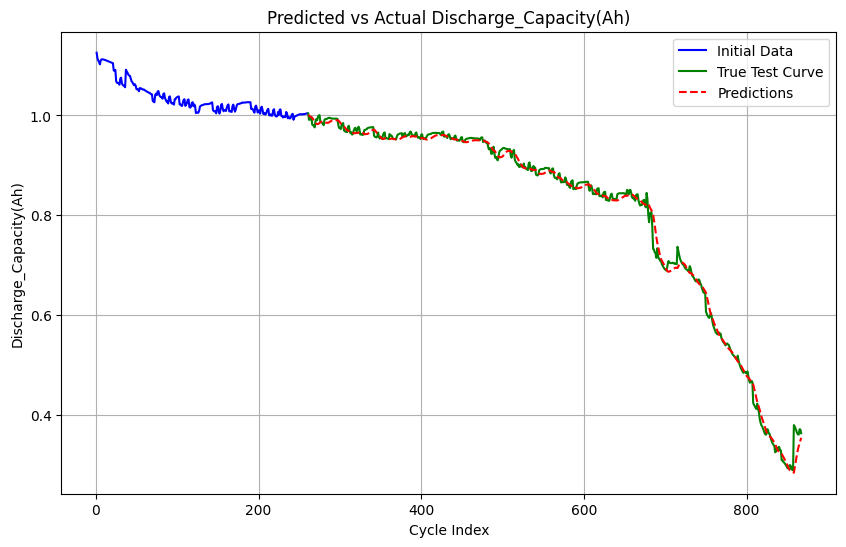

In [45]:
plot_predictions(model_2, dfs, TEST_BATTERY, generate_sliding_window_data, MIN, DIFF, device, 'Discharge_Capacity(Ah)', -1, 30)

## ABC (Artificial Bee Colony) BiGRU Model

In [26]:
bounds = np.array([
    [16, 128],    # Hidden size
    [1e-4, 1e-2], # Learning rate
    [0.1, 0.5]    # Dropout
])

# Run the ABC algorithm with the provided dataloaders
best_params, best_mse = abc_algorithm(bounds, CALCE_train_dataloaders[0], CALCE_val_dataloaders[0], device, n_solutions=10, max_iters=20)
print("Best Parameters:", best_params)
print("Best MSE:", best_mse)

Iteration 1/20, Best Fitness (MSE): 0.00015214825407383614
Iteration 2/20, Best Fitness (MSE): 0.00015214825407383614
Iteration 3/20, Best Fitness (MSE): 0.00015214825407383614
Iteration 4/20, Best Fitness (MSE): 0.00014483308950730134
Iteration 5/20, Best Fitness (MSE): 0.00014483308950730134
Iteration 6/20, Best Fitness (MSE): 0.00014483308950730134
Iteration 7/20, Best Fitness (MSE): 0.00014483308950730134
Iteration 8/20, Best Fitness (MSE): 0.00014483308950730134
Iteration 9/20, Best Fitness (MSE): 0.00014483308950730134
Iteration 10/20, Best Fitness (MSE): 0.00014483308950730134
Iteration 11/20, Best Fitness (MSE): 0.00014483308950730134
Iteration 12/20, Best Fitness (MSE): 0.00014483308950730134
Iteration 13/20, Best Fitness (MSE): 0.00014483308950730134
Iteration 14/20, Best Fitness (MSE): 0.00014483308950730134
Iteration 15/20, Best Fitness (MSE): 0.00014483308950730134
Iteration 16/20, Best Fitness (MSE): 0.00014483308950730134
Iteration 17/20, Best Fitness (MSE): 0.0001448330

Epoch 1: Validation loss improved to 0.008324617898324504. Model saved!
Epoch 1/50, Train Loss: 0.18923215413345926, Val Loss: 0.008324617898324504
Epoch 2: Validation loss improved to 0.005868109903531149. Model saved!
Epoch 2/50, Train Loss: 0.01246357069260651, Val Loss: 0.005868109903531149
Epoch 3: Validation loss improved to 0.004453497749636881. Model saved!
Epoch 3/50, Train Loss: 0.01035318405727946, Val Loss: 0.004453497749636881
Epoch 4: Validation loss improved to 0.0030526745213137474. Model saved!
Epoch 4/50, Train Loss: 0.008709139904127486, Val Loss: 0.0030526745213137474
Epoch 5: Validation loss improved to 0.0022307882318273187. Model saved!
Epoch 5/50, Train Loss: 0.007314953810325073, Val Loss: 0.0022307882318273187
Epoch 6: Validation loss improved to 0.0014050855570530985. Model saved!
Epoch 6/50, Train Loss: 0.005689001379294261, Val Loss: 0.0014050855570530985
Epoch 7: Validation loss improved to 0.0006177224659040803. Model saved!
Epoch 7/50, Train Loss: 0.0052

C:\Users\shubham mate\AppData\Local\Temp\ipykernel_18176\349383212.py:23: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model_3.load_state_dict(torch.load(ModelOutputConstan

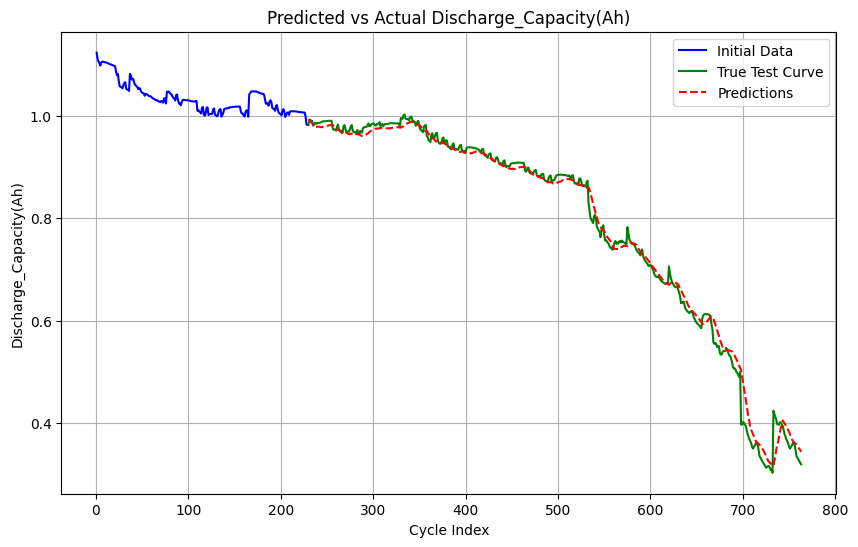

Epoch 1: Validation loss improved to 0.8541044071316719. Model saved!
Epoch 1/50, Train Loss: 0.9847906616426283, Val Loss: 0.8541044071316719
Epoch 2: Validation loss improved to 0.7133835628628731. Model saved!
Epoch 2/50, Train Loss: 0.7945953203785804, Val Loss: 0.7133835628628731
Epoch 3: Validation loss improved to 0.5946823209524155. Model saved!
Epoch 3/50, Train Loss: 0.6655089662921044, Val Loss: 0.5946823209524155
Epoch 4: Validation loss improved to 0.4552447758615017. Model saved!
Epoch 4/50, Train Loss: 0.5344389547263423, Val Loss: 0.4552447758615017
Epoch 5: Validation loss improved to 0.32736132480204105. Model saved!
Epoch 5/50, Train Loss: 0.4041980879922067, Val Loss: 0.32736132480204105
Epoch 6: Validation loss improved to 0.011871643597260118. Model saved!
Epoch 6/50, Train Loss: 0.12129464541231433, Val Loss: 0.011871643597260118
Epoch 7: Validation loss improved to 0.007845809945138171. Model saved!
Epoch 7/50, Train Loss: 0.011582156057439504, Val Loss: 0.00784

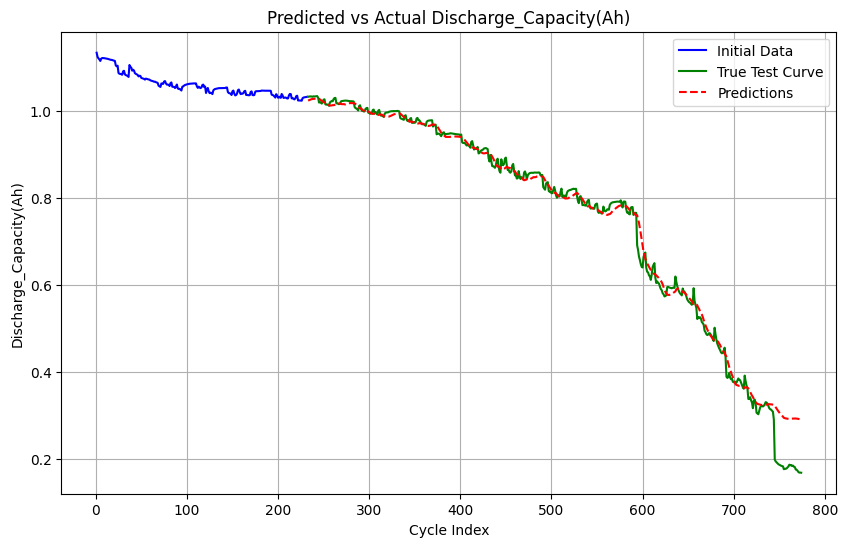

Epoch 1: Validation loss improved to 0.014038440771400928. Model saved!
Epoch 1/50, Train Loss: 0.20611890734483798, Val Loss: 0.014038440771400928
Epoch 2: Validation loss improved to 0.011098788119852543. Model saved!
Epoch 2/50, Train Loss: 0.014640124918272098, Val Loss: 0.011098788119852543
Epoch 3: Validation loss improved to 0.008257496605316798. Model saved!
Epoch 3/50, Train Loss: 0.012112254354481896, Val Loss: 0.008257496605316798
Epoch 4: Validation loss improved to 0.005777240777388215. Model saved!
Epoch 4/50, Train Loss: 0.009926547319628299, Val Loss: 0.005777240777388215
Epoch 5: Validation loss improved to 0.003938833049808939. Model saved!
Epoch 5/50, Train Loss: 0.008446587536794444, Val Loss: 0.003938833049808939
Epoch 6: Validation loss improved to 0.002422960684634745. Model saved!
Epoch 6/50, Train Loss: 0.006559018670426061, Val Loss: 0.002422960684634745
Epoch 7: Validation loss improved to 0.0012246302561834455. Model saved!
Epoch 7/50, Train Loss: 0.00468621

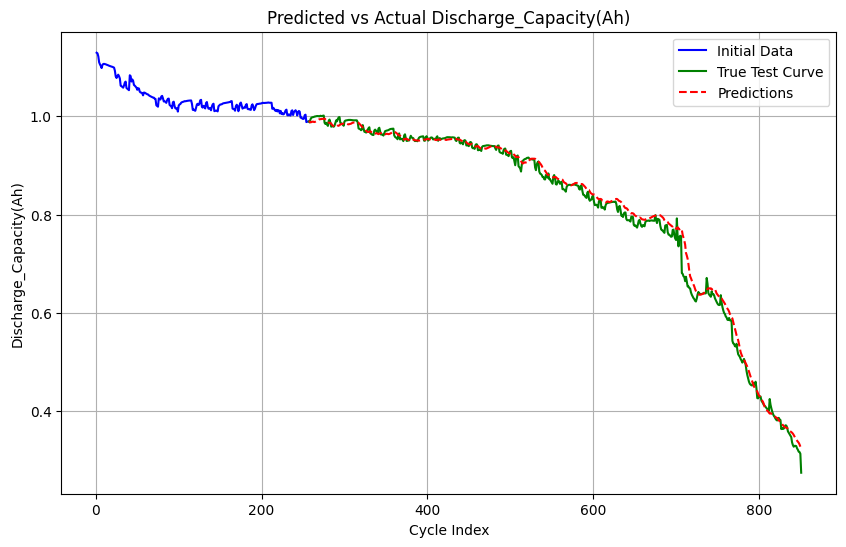

Epoch 1: Validation loss improved to 0.011370040724674861. Model saved!
Epoch 1/50, Train Loss: 0.33986562716190594, Val Loss: 0.011370040724674861
Epoch 2: Validation loss improved to 0.0020474332462375364. Model saved!
Epoch 2/50, Train Loss: 0.012983963951089625, Val Loss: 0.0020474332462375364
Epoch 3: Validation loss improved to 0.001684963198689123. Model saved!
Epoch 3/50, Train Loss: 0.009538822657412897, Val Loss: 0.001684963198689123
Epoch 4: Validation loss improved to 0.0012206805947547158. Model saved!
Epoch 4/50, Train Loss: 0.009239866114142587, Val Loss: 0.0012206805947547158
Epoch 5: Validation loss improved to 0.0009437730923915903. Model saved!
Epoch 5/50, Train Loss: 0.008107743581157114, Val Loss: 0.0009437730923915903
Epoch 6: Validation loss improved to 0.0007460908265784383. Model saved!
Epoch 6/50, Train Loss: 0.007846221225178343, Val Loss: 0.0007460908265784383
Epoch 7: Validation loss improved to 0.0005766337543415527. Model saved!
Epoch 7/50, Train Loss: 0.

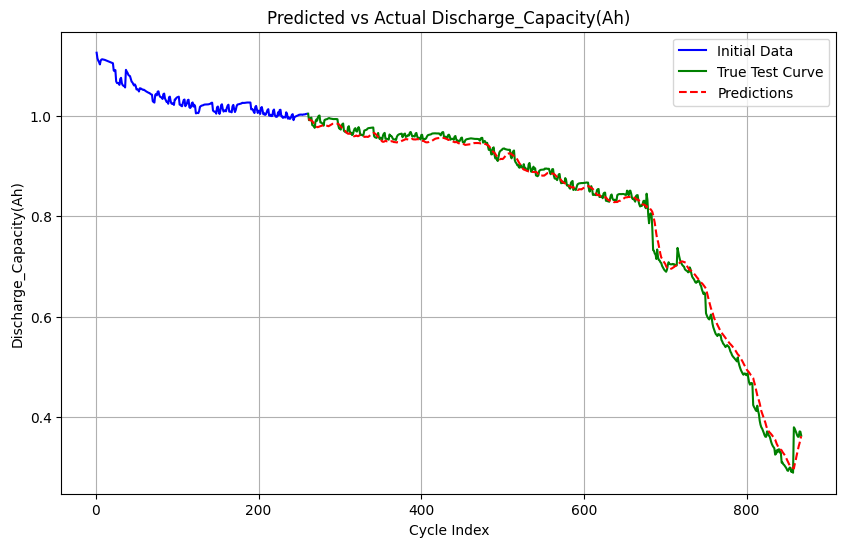

In [28]:

for i in range(4):
    model_3 = BiGRUModel(input_size=10, hidden_size=int(round(best_params[0])), dropout=best_params[2]).to(device)
    optimizer = torch.optim.Adam(model_3.parameters(), lr=1e-3)
    criterion = torch.nn.MSELoss()
    EPOCHS = 50
    
    train_model(
        model=model_3,
        train_dataloader=CALCE_train_dataloaders[i],
        val_dataloader=CALCE_val_dataloaders[i],
        optimizer=optimizer,
        criterion=criterion,
        device=device,
        min_val=MIN,
        diff_val=DIFF,
        epochs=EPOCHS,
        unsqueeze_dim=1,
        log_interval=1,
        patience=5,
        save_path=ModelOutputConstants.CALCE_OUTPUT_PATH.value / f'abc_bigru{test_and_trains[i][0]}.pth'
    )
    
    model_3.load_state_dict(torch.load(ModelOutputConstants.CALCE_OUTPUT_PATH.value / f'abc_bigru{test_and_trains[i][0]}.pth'))
    model_3.to(device)
    
    metrics = evaluate_model(model_3, CALCE_test_dataloaders[i], device, MIN, DIFF, 1)
    print(f'RMSE: {metrics['RMSE']}\nMAE: {metrics['MAE']}')

    plot_predictions(model_3, dfs, test_and_trains[i][0], generate_sliding_window_data, MIN, DIFF, device, 'Discharge_Capacity(Ah)', 1, 30)

In [48]:
metrics = evaluate_model(model_3, test_dataloader, device, MIN, DIFF, 1)
print(f'RMSE: {metrics['RMSE']}\nMAE: {metrics['MAE']}')

RMSE: 0.005899988979855457
MAE: 0.003977795645037544


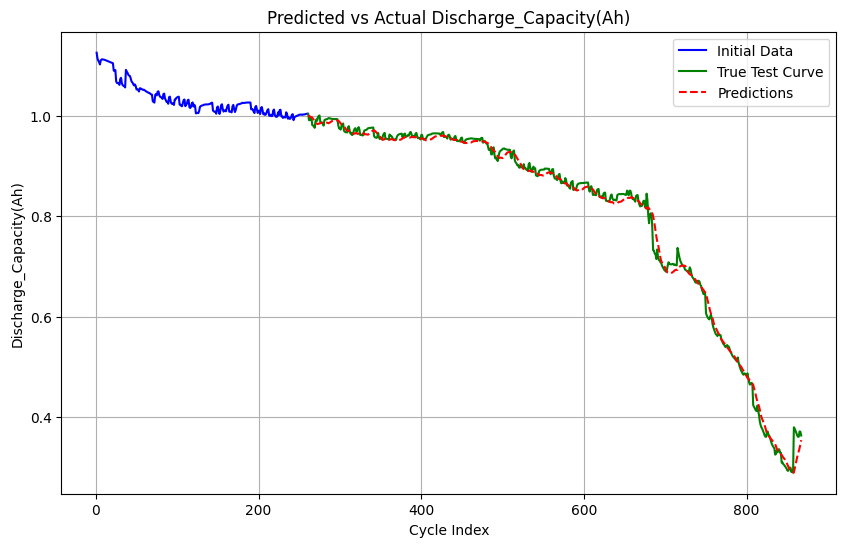

In [49]:
plot_predictions(model_3, dfs, TEST_BATTERY, generate_sliding_window_data, MIN, DIFF, device, 'Discharge_Capacity(Ah)', 1, 30)

## CNN - DBLSTM Model

C:\Users\shubham mate\Desktop\Programming\Python\Battery RUL Project\venv\Lib\site-packages\torch\nn\modules\conv.py:370: UserWarning: Using padding='same' with even kernel lengths and odd dilation may require a zero-padded copy of the input be created (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\builder\windows\pytorch\aten\src\ATen\native\Convolution.cpp:1037.)
  return F.conv1d(


Epoch 1: Validation loss improved to 0.0012443890991562512. Model saved!
Epoch 1/50, Train Loss: 0.02473099535517019, Val Loss: 0.0012443890991562512
Epoch 2: Validation loss improved to 0.00041248109482694417. Model saved!
Epoch 2/50, Train Loss: 0.0011963242662116705, Val Loss: 0.00041248109482694417
Epoch 3: Validation loss improved to 0.000293546489047003. Model saved!
Epoch 3/50, Train Loss: 0.0007254667067290059, Val Loss: 0.000293546489047003
Epoch 4: No improvement. (1/5)
Epoch 4/50, Train Loss: 0.0006459282111233822, Val Loss: 0.0009638202682253905
Epoch 5: Validation loss improved to 0.00013966570827506075. Model saved!
Epoch 5/50, Train Loss: 0.0005391788605089871, Val Loss: 0.00013966570827506075
Epoch 6: Validation loss improved to 0.00013160565413272707. Model saved!
Epoch 6/50, Train Loss: 0.0004189595254560587, Val Loss: 0.00013160565413272707
Epoch 7: No improvement. (1/5)
Epoch 7/50, Train Loss: 0.0004991558224930721, Val Loss: 0.0003269121079938486
Epoch 8: No improv

C:\Users\shubham mate\AppData\Local\Temp\ipykernel_18176\1951592573.py:24: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model_4.load_state_dict(torch.load(ModelOutputConsta

RMSE: 0.013030468304619696
MAE: 0.01006929302944782


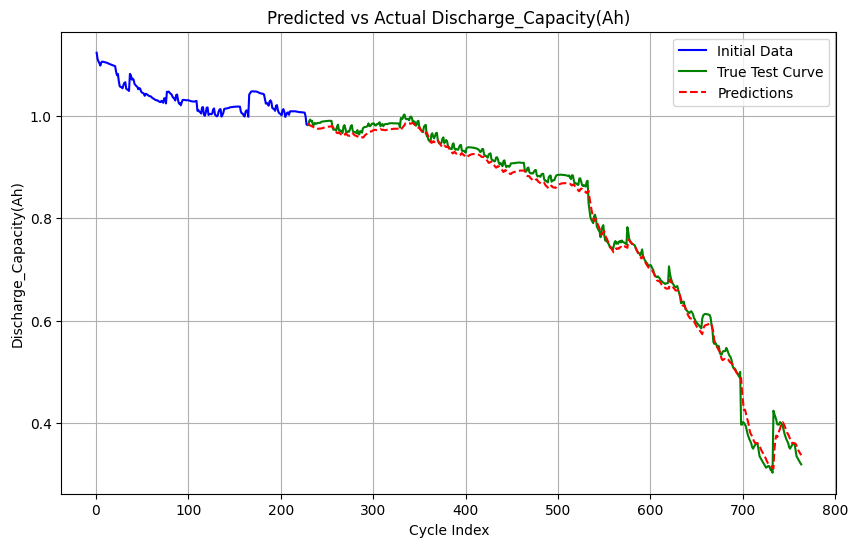

Epoch 1: Validation loss improved to 0.0360404800157994. Model saved!
Epoch 1/50, Train Loss: 0.20180342304370097, Val Loss: 0.0360404800157994
Epoch 2: Validation loss improved to 0.011950062296818942. Model saved!
Epoch 2/50, Train Loss: 0.030576229516056277, Val Loss: 0.011950062296818942
Epoch 3: Validation loss improved to 0.0010234730725642294. Model saved!
Epoch 3/50, Train Loss: 0.004187840581571143, Val Loss: 0.0010234730725642294
Epoch 4: Validation loss improved to 0.0003061868746954133. Model saved!
Epoch 4/50, Train Loss: 0.0008934436674838164, Val Loss: 0.0003061868746954133
Epoch 5: No improvement. (1/5)
Epoch 5/50, Train Loss: 0.0005379781601556217, Val Loss: 0.0006901661836309358
Epoch 6: No improvement. (2/5)
Epoch 6/50, Train Loss: 0.0004522336316914598, Val Loss: 0.0004844780851271935
Epoch 7: Validation loss improved to 0.0002017203137256729. Model saved!
Epoch 7/50, Train Loss: 0.0005314039083332905, Val Loss: 0.0002017203137256729
Epoch 8: No improvement. (1/5)
E

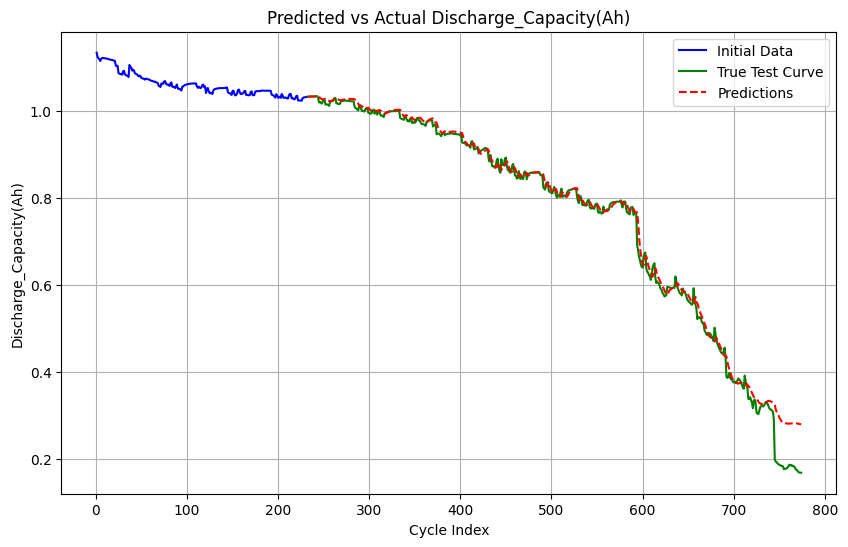

Epoch 1: Validation loss improved to 0.00045864666365863136. Model saved!
Epoch 1/50, Train Loss: 0.04213145334457901, Val Loss: 0.00045864666365863136
Epoch 2: No improvement. (1/5)
Epoch 2/50, Train Loss: 0.001483649606719458, Val Loss: 0.0009036572999320924
Epoch 3: Validation loss improved to 0.000315996651382496. Model saved!
Epoch 3/50, Train Loss: 0.0008608468815509696, Val Loss: 0.000315996651382496
Epoch 4: No improvement. (1/5)
Epoch 4/50, Train Loss: 0.000662424132557741, Val Loss: 0.0007656340526106457
Epoch 5: No improvement. (2/5)
Epoch 5/50, Train Loss: 0.0006951249757548794, Val Loss: 0.00035742316977120935
Epoch 6: No improvement. (3/5)
Epoch 6/50, Train Loss: 0.0007514392467176852, Val Loss: 0.001219090501156946
Epoch 7: No improvement. (4/5)
Epoch 7/50, Train Loss: 0.0010371540067959965, Val Loss: 0.0005312349802503983
Epoch 8: No improvement. (5/5)
Early stopping triggered. Training stopped.
RMSE: 0.010760041979812396
MAE: 0.007730346031132198


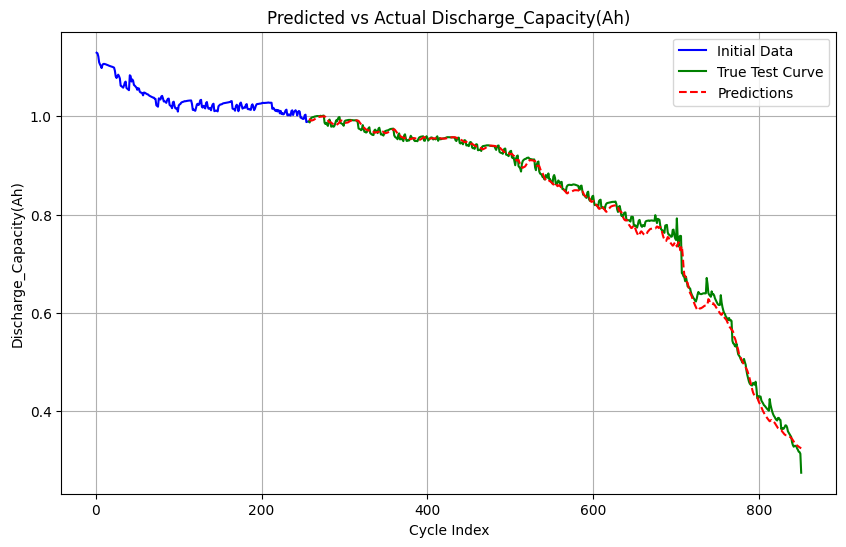

Epoch 1: Validation loss improved to 0.004303191664318243. Model saved!
Epoch 1/50, Train Loss: 0.10840840836576486, Val Loss: 0.004303191664318243
Epoch 2: Validation loss improved to 0.0005372133979108185. Model saved!
Epoch 2/50, Train Loss: 0.0018030778271584157, Val Loss: 0.0005372133979108185
Epoch 3: Validation loss improved to 0.00019882764560558524. Model saved!
Epoch 3/50, Train Loss: 0.0011640929970179953, Val Loss: 0.00019882764560558524
Epoch 4: No improvement. (1/5)
Epoch 4/50, Train Loss: 0.0007101465424797024, Val Loss: 0.00038745036775556706
Epoch 5: No improvement. (2/5)
Epoch 5/50, Train Loss: 0.0006651450922787663, Val Loss: 0.0003949248290155083
Epoch 6: No improvement. (3/5)
Epoch 6/50, Train Loss: 0.0007624460970765864, Val Loss: 0.000436650754030173
Epoch 7: No improvement. (4/5)
Epoch 7/50, Train Loss: 0.0008099765050169712, Val Loss: 0.000475054649480929
Epoch 8: Validation loss improved to 0.00012985685001088617. Model saved!
Epoch 8/50, Train Loss: 0.0004790

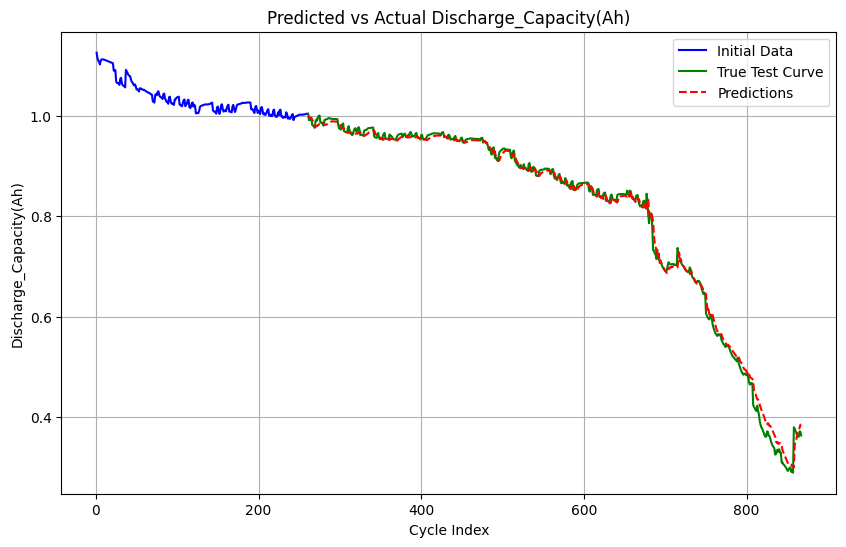

In [29]:

for i in range(4):
    model_4 = CNN_DBLSTM_Model([24, 48, 72], 128, 4).to(device)
    optimizer = torch.optim.Adam(model_4.parameters())
    criterion = torch.nn.MSELoss()
    EPOCHS = 50
    
    
    train_model(
        model=model_4,
        train_dataloader=CALCE_train_dataloaders[i],
        val_dataloader=CALCE_val_dataloaders[i],
        optimizer=optimizer,
        criterion=criterion,
        device=device,
        min_val=MIN,
        diff_val=DIFF,
        epochs=EPOCHS,
        unsqueeze_dim=1,
        log_interval=1,
        patience=5,
        save_path=ModelOutputConstants.CALCE_OUTPUT_PATH.value / f'cnn_dblstm{test_and_trains[i][0]}.pth'
    )
    
    model_4.load_state_dict(torch.load(ModelOutputConstants.CALCE_OUTPUT_PATH.value / f'cnn_dblstm{test_and_trains[i][0]}.pth'))
    model_4.to(device)

    metrics = evaluate_model(model_4, CALCE_test_dataloaders[i], device, MIN, DIFF, 1)
    print(f'RMSE: {metrics['RMSE']}\nMAE: {metrics['MAE']}')

    plot_predictions(model_4, dfs, test_and_trains[i][0], generate_sliding_window_data, MIN, DIFF, device, 'Discharge_Capacity(Ah)', 1, 30)

In [51]:
metrics = evaluate_model(model_4, test_dataloader, device, MIN, DIFF, 1)
print(f'RMSE: {metrics['RMSE']}\nMAE: {metrics['MAE']}')

RMSE: 0.005643505035701092
MAE: 0.003953174975152327


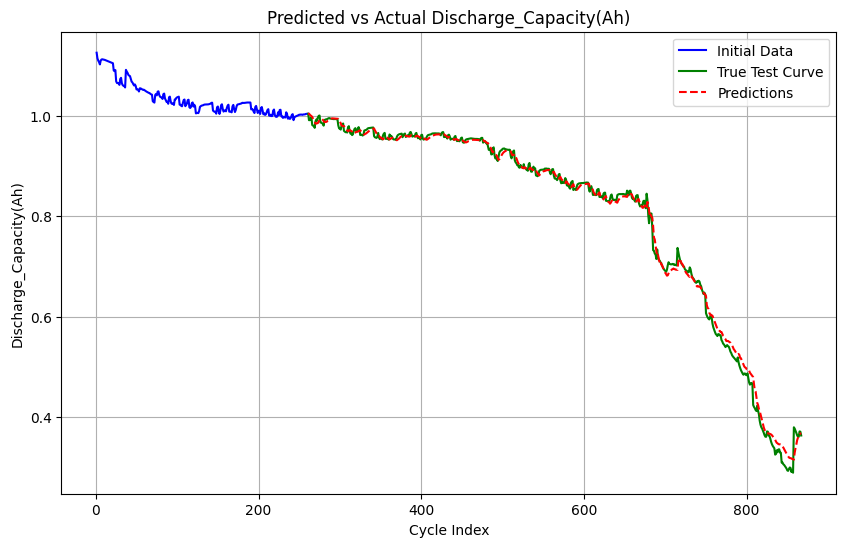

In [52]:
plot_predictions(model_4, dfs, TEST_BATTERY, generate_sliding_window_data, MIN, DIFF, device, 'Discharge_Capacity(Ah)', 1, 30)

## CNN - ASTLSTM

Epoch 1: Validation loss improved to 0.39030449092388153. Model saved!
Epoch 1/50, Train Loss: 0.6052633889259831, Val Loss: 0.39030449092388153
Epoch 2: Validation loss improved to 0.03609190369024873. Model saved!
Epoch 2/50, Train Loss: 0.13004316765093996, Val Loss: 0.03609190369024873
Epoch 3: Validation loss improved to 0.03315455699339509. Model saved!
Epoch 3/50, Train Loss: 0.03598610498011112, Val Loss: 0.03315455699339509
Epoch 4: Validation loss improved to 0.025338314881082624. Model saved!
Epoch 4/50, Train Loss: 0.03146644198005238, Val Loss: 0.025338314881082624
Epoch 5: Validation loss improved to 0.013262506079627201. Model saved!
Epoch 5/50, Train Loss: 0.02027199163492168, Val Loss: 0.013262506079627201
Epoch 6: Validation loss improved to 0.001735511399601819. Model saved!
Epoch 6/50, Train Loss: 0.006891510042835087, Val Loss: 0.001735511399601819
Epoch 7: Validation loss improved to 0.0005549077081923315. Model saved!
Epoch 7/50, Train Loss: 0.0006954314451450632

C:\Users\shubham mate\AppData\Local\Temp\ipykernel_18176\2511820452.py:24: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model_5.load_state_dict(torch.load(ModelOutputConsta

RMSE: 0.013293722684830925
MAE: 0.007922152453597555


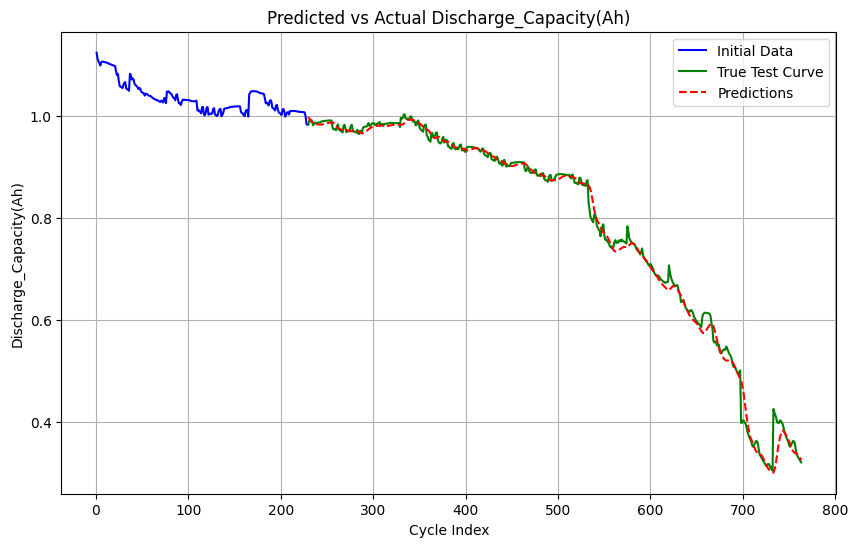

Epoch 1: Validation loss improved to 0.09668630920350552. Model saved!
Epoch 1/50, Train Loss: 0.39070559797748444, Val Loss: 0.09668630920350552
Epoch 2: Validation loss improved to 0.026962097850628197. Model saved!
Epoch 2/50, Train Loss: 0.03378560511215079, Val Loss: 0.026962097850628197
Epoch 3: Validation loss improved to 0.01924869342474267. Model saved!
Epoch 3/50, Train Loss: 0.02141197121912433, Val Loss: 0.01924869342474267
Epoch 4: Validation loss improved to 0.007864341256208718. Model saved!
Epoch 4/50, Train Loss: 0.011619808182360665, Val Loss: 0.007864341256208718
Epoch 5: Validation loss improved to 0.0022892737470101565. Model saved!
Epoch 5/50, Train Loss: 0.004080764605708781, Val Loss: 0.0022892737470101565
Epoch 6: Validation loss improved to 0.0004311549932936032. Model saved!
Epoch 6/50, Train Loss: 0.0008147706012682794, Val Loss: 0.0004311549932936032
Epoch 7: Validation loss improved to 0.0002996370867549558. Model saved!
Epoch 7/50, Train Loss: 0.000294034

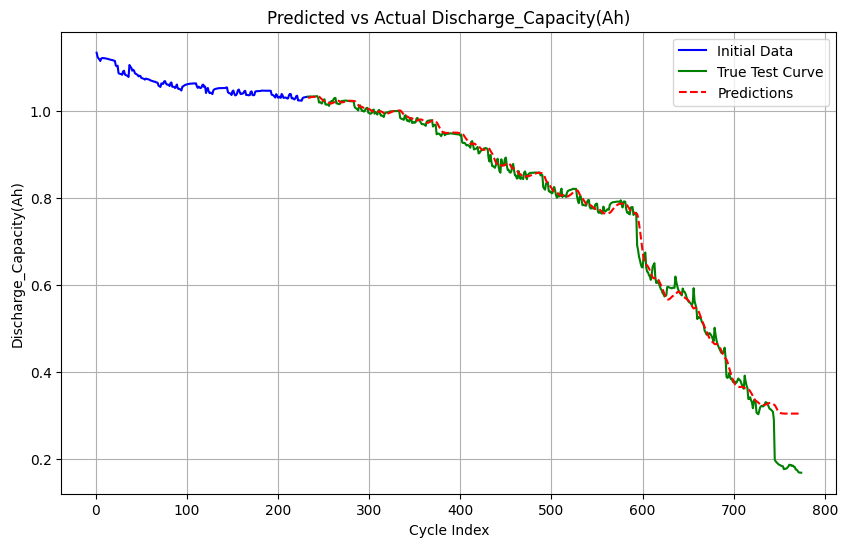

Epoch 1: Validation loss improved to 0.38179757197697956. Model saved!
Epoch 1/50, Train Loss: 0.6628962640961011, Val Loss: 0.38179757197697956
Epoch 2: Validation loss improved to 0.035711298882961276. Model saved!
Epoch 2/50, Train Loss: 0.11931824351971348, Val Loss: 0.035711298882961276
Epoch 3: Validation loss improved to 0.02545893006026745. Model saved!
Epoch 3/50, Train Loss: 0.029006800319378575, Val Loss: 0.02545893006026745
Epoch 4: Validation loss improved to 0.009455373076101144. Model saved!
Epoch 4/50, Train Loss: 0.01631894437596202, Val Loss: 0.009455373076101144
Epoch 5: Validation loss improved to 0.0016694258782081306. Model saved!
Epoch 5/50, Train Loss: 0.0035406686084267372, Val Loss: 0.0016694258782081306
Epoch 6: Validation loss improved to 0.001338063277459393. Model saved!
Epoch 6/50, Train Loss: 0.0010721548717507782, Val Loss: 0.001338063277459393
Epoch 7: Validation loss improved to 0.00113825544831343. Model saved!
Epoch 7/50, Train Loss: 0.0009058249571

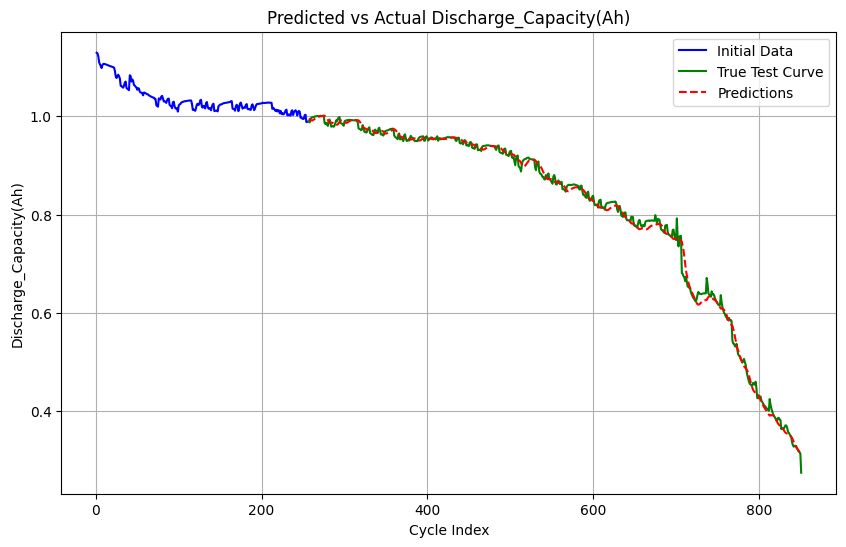

Epoch 1: Validation loss improved to 0.15743058522542316. Model saved!
Epoch 1/50, Train Loss: 0.3134636111178641, Val Loss: 0.15743058522542316
Epoch 2: Validation loss improved to 0.02974632059534391. Model saved!
Epoch 2/50, Train Loss: 0.055933946333194186, Val Loss: 0.02974632059534391
Epoch 3: Validation loss improved to 0.018069133535027503. Model saved!
Epoch 3/50, Train Loss: 0.028774855705767363, Val Loss: 0.018069133535027503
Epoch 4: Validation loss improved to 0.002272791283515592. Model saved!
Epoch 4/50, Train Loss: 0.010974348203073872, Val Loss: 0.002272791283515592
Epoch 5: Validation loss improved to 0.000613693951163441. Model saved!
Epoch 5/50, Train Loss: 0.0015298853190793356, Val Loss: 0.000613693951163441
Epoch 6: Validation loss improved to 0.000482942332746461. Model saved!
Epoch 6/50, Train Loss: 0.0008875270807223741, Val Loss: 0.000482942332746461
Epoch 7: Validation loss improved to 0.00042456882268500823. Model saved!
Epoch 7/50, Train Loss: 0.0007252502

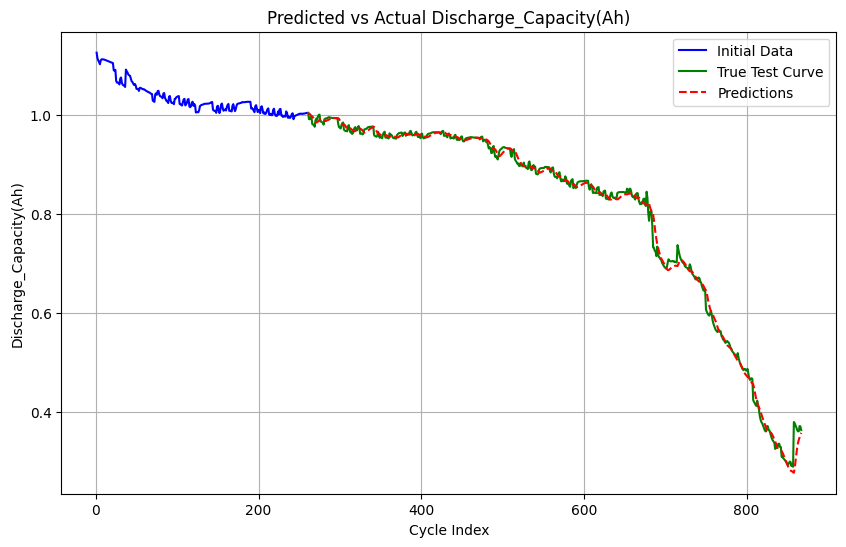

In [30]:

for i in range(4):
    model_5 = CNN_ASTLSTM(46, [24, 28]).to(device)
    optimizer = torch.optim.Adam(model_5.parameters(), lr=5e-4)
    criterion = torch.nn.MSELoss()
    EPOCHS = 50
    
    
    train_model(
        model=model_5,
        train_dataloader=CALCE_train_dataloaders[i],
        val_dataloader=CALCE_val_dataloaders[i],
        optimizer=optimizer,
        criterion=criterion,
        device=device,
        min_val=MIN,
        diff_val=DIFF,
        epochs=EPOCHS,
        unsqueeze_dim=1,
        log_interval=1,
        patience=10,
        save_path=ModelOutputConstants.CALCE_OUTPUT_PATH.value / f'cnn_astlstm_{test_and_trains[i][0]}.pth'
    )
    
    model_5.load_state_dict(torch.load(ModelOutputConstants.CALCE_OUTPUT_PATH.value / f'cnn_astlstm_{test_and_trains[i][0]}.pth'))
    model_5.to(device)

    metrics = evaluate_model(model_5, CALCE_test_dataloaders[i], device, MIN, DIFF, 1)
    print(f'RMSE: {metrics['RMSE']}\nMAE: {metrics['MAE']}')

    plot_predictions(model_5, dfs, test_and_trains[i][0], generate_sliding_window_data, MIN, DIFF, device, 'Discharge_Capacity(Ah)', 1, 30)

In [49]:
metrics = evaluate_model(model_5, test_dataloader, device, MIN, DIFF, 1)
print(f'RMSE: {metrics['RMSE']}\nMAE: {metrics['MAE']}')

RMSE: 0.011298141927561706
MAE: 0.007304784589420969


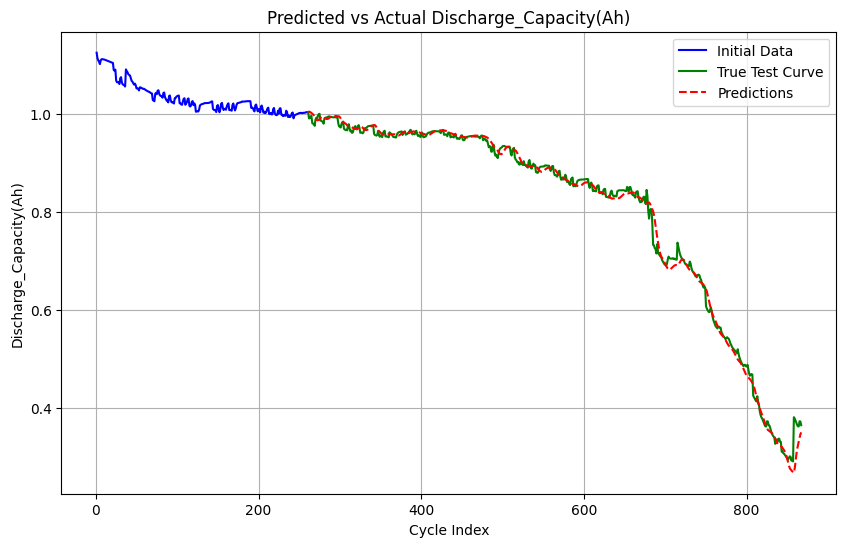

In [50]:
plot_predictions(model_5, dfs, TEST_BATTERY, generate_sliding_window_data, MIN, DIFF, device, 'Discharge_Capacity(Ah)', 1, 30)

# NASA Dataset

In [5]:
nasa_dfs = {NASADatasetConstants.BATTERY_NAMES.value[i]: \
       pd.read_csv(NASADatasetConstants.BATTERY_FILEPATHS.value[i]) for i in range(len(NASADatasetConstants.BATTERY_NAMES.value))}
nasa_dfs

{'B0005':      cycle  amb_temp              date_time  voltage_battery  current_battery  \
 0        1        24  02 Apr 2008, 15:25:41         3.277170        -0.006528   
 1        3        24  02 Apr 2008, 19:43:48         3.300245        -0.000448   
 2        5        24  03 Apr 2008, 00:01:06         3.327451         0.001026   
 3        7        24  03 Apr 2008, 04:16:37         3.314182        -0.002234   
 4        9        24  03 Apr 2008, 08:33:25         3.305497         0.000009   
 ..     ...       ...                    ...              ...              ...   
 163    599        24  26 May 2008, 10:44:38         3.615561        -0.002548   
 164    603        24  26 May 2008, 15:30:43         3.621191        -0.002460   
 165    607        24  26 May 2008, 20:21:04         3.619185         0.000478   
 166    611        24  27 May 2008, 15:52:41         3.595365        -0.002342   
 167    613        24  27 May 2008, 20:45:42         3.589937        -0.000583   
 
     

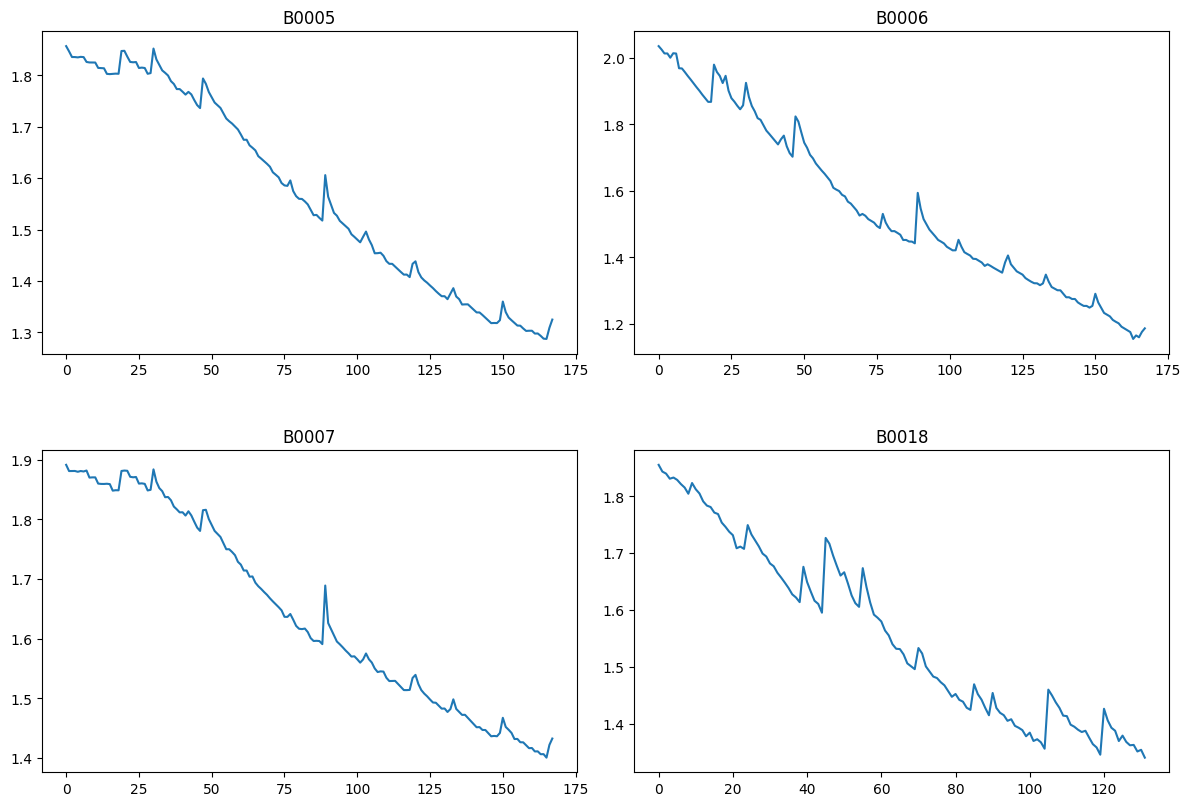

In [6]:
fig, ax = plt.subplots(nrows=int(len(nasa_dfs)/2), ncols=2, figsize=(12, 8))
fig.tight_layout()
plt.subplots_adjust(hspace=0.3)

for i, (battery_number, df) in enumerate(nasa_dfs.items()):
    ax[int(i/2), i%2].plot(df.index, df['capacity'])
    ax[int(i/2), i%2].set_title(f'{battery_number}')

plt.show()

In [7]:
# Create a list containing test and training battery numbers for each case
test_and_trains = []

for battery_name in NASADatasetConstants.BATTERY_NAMES.value:
    excluded_list = [x for x in NASADatasetConstants.BATTERY_NAMES.value if x != battery_name]
    test_and_trains.append((battery_name, excluded_list))

test_and_trains

[('B0005', ['B0006', 'B0007', 'B0018']),
 ('B0006', ['B0005', 'B0007', 'B0018']),
 ('B0007', ['B0005', 'B0006', 'B0018']),
 ('B0018', ['B0005', 'B0006', 'B0007'])]

In [8]:
NASA_train_dataloaders = []
NASA_val_dataloaders = []
NASA_test_dataloaders = []

for test_battery, training_batteries in test_and_trains:
    
    trainX = []
    trainY = []
    
    for battery in training_batteries:
        x, y = generate_sliding_window_data(nasa_dfs[battery]['capacity'], window_size=5)
        trainX.extend(x)
        trainY.extend(y)
    
    trainX, trainY = np.array(trainX), np.array(trainY)
    
    testX, testY = generate_sliding_window_data(nasa_dfs[test_battery]['capacity'], window_size=5)
    testX, testY = np.array(testX), np.array(testY)
    
    train_dataset = CustomDataset(trainX, trainY)
    
    dataset_size = len(train_dataset)
    train_size = int(dataset_size * TRAIN_RATIO)
    val_size = dataset_size - train_size
    train_subset, val_subset = random_split(train_dataset, [train_size, val_size])
    
    train_dataloader = DataLoader(train_subset, batch_size=32, shuffle=True)
    val_dataloader = DataLoader(val_subset, batch_size=32, shuffle=True)
    
    test_dataset = CustomDataset(testX, testY)
    test_dataloader = DataLoader(test_dataset, batch_size=32, shuffle=True)

    NASA_train_dataloaders.append(train_dataloader)
    NASA_val_dataloaders.append(val_dataloader)
    NASA_test_dataloaders.append(test_dataloader)

In [9]:
NASA_train_dataloaders, NASA_test_dataloaders, NASA_val_dataloaders

([<torch.utils.data.dataloader.DataLoader at 0x1d35890c7d0>,
  <torch.utils.data.dataloader.DataLoader at 0x1d358795d00>])

In [32]:
MIN = 0.0
MAX = 2.0
DIFF = MAX - MIN

## TCN-GRU-DNN Model

Epoch 1: Validation loss improved to 0.7447273929913839. Model saved!
Epoch 1/200, Train Loss: 0.7528658956289291, Val Loss: 0.7447273929913839
Epoch 2: Validation loss improved to 0.6989097396532694. Model saved!
Epoch 2/200, Train Loss: 0.6629006862640381, Val Loss: 0.6989097396532694
Epoch 3: Validation loss improved to 0.6478603879610697. Model saved!
Epoch 3/200, Train Loss: 0.5947294135888418, Val Loss: 0.6478603879610697
Epoch 4: Validation loss improved to 0.5384489297866821. Model saved!
Epoch 4/200, Train Loss: 0.5507633611559868, Val Loss: 0.5384489297866821
Epoch 5: Validation loss improved to 0.4984582265218099. Model saved!
Epoch 5/200, Train Loss: 0.5160447433590889, Val Loss: 0.4984582265218099
Epoch 6: Validation loss improved to 0.46290846665700275. Model saved!
Epoch 6/200, Train Loss: 0.4903961519400279, Val Loss: 0.46290846665700275
Epoch 7: Validation loss improved to 0.4292283058166504. Model saved!
Epoch 7/200, Train Loss: 0.45199736456076306, Val Loss: 0.429228

C:\Users\shubham mate\AppData\Local\Temp\ipykernel_13228\1457892803.py:24: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model_1.load_state_dict(torch.load(ModelOutputConsta

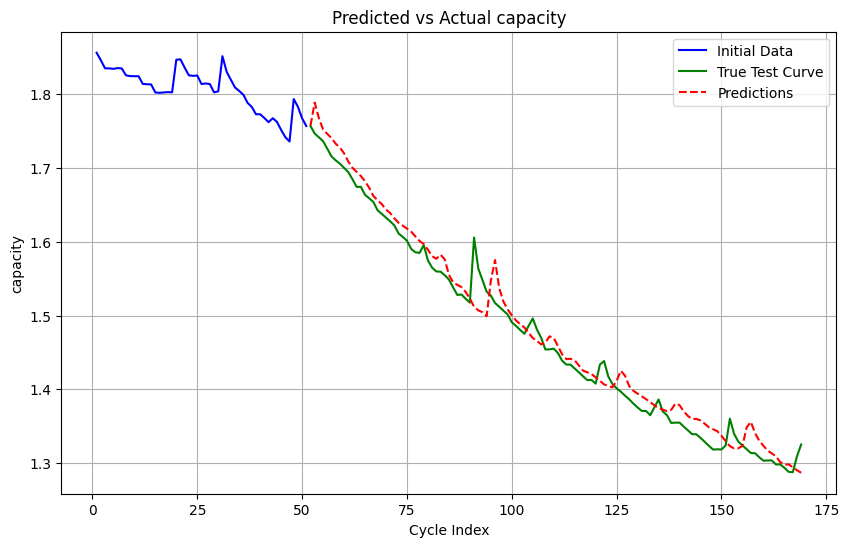

Epoch 1: Validation loss improved to 0.5499623616536459. Model saved!
Epoch 1/200, Train Loss: 0.5654603143533071, Val Loss: 0.5499623616536459
Epoch 2: Validation loss improved to 0.5306751330693563. Model saved!
Epoch 2/200, Train Loss: 0.5331442505121231, Val Loss: 0.5306751330693563
Epoch 3: Validation loss improved to 0.5056994557380676. Model saved!
Epoch 3/200, Train Loss: 0.49834493299325305, Val Loss: 0.5056994557380676
Epoch 4: Validation loss improved to 0.43925441304842633. Model saved!
Epoch 4/200, Train Loss: 0.459016390144825, Val Loss: 0.43925441304842633
Epoch 5: Validation loss improved to 0.33610321084658307. Model saved!
Epoch 5/200, Train Loss: 0.3927539711197217, Val Loss: 0.33610321084658307
Epoch 6: Validation loss improved to 0.23604369660218558. Model saved!
Epoch 6/200, Train Loss: 0.2983914762735367, Val Loss: 0.23604369660218558
Epoch 7: Validation loss improved to 0.14377561708291373. Model saved!
Epoch 7/200, Train Loss: 0.20252453535795212, Val Loss: 0.1

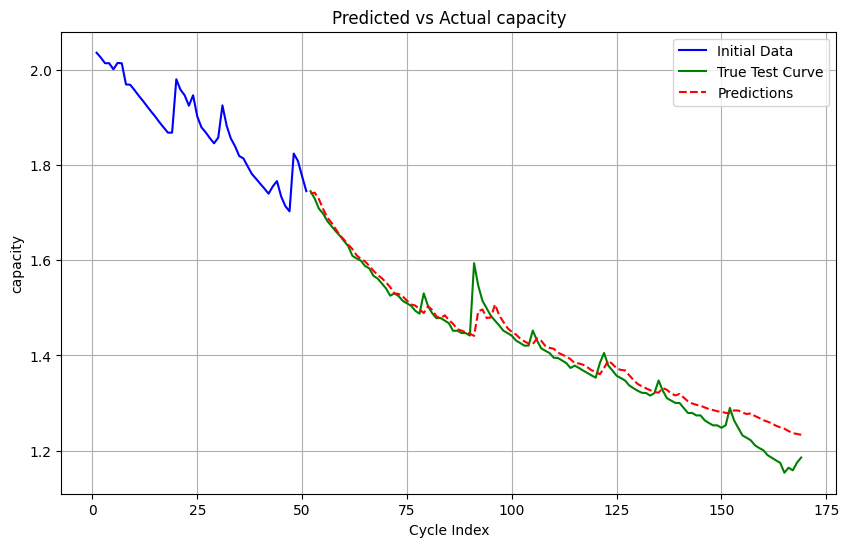

Epoch 1: Validation loss improved to 0.2605740229288737. Model saved!
Epoch 1/200, Train Loss: 0.26906389370560646, Val Loss: 0.2605740229288737
Epoch 2: Validation loss improved to 0.24671612679958344. Model saved!
Epoch 2/200, Train Loss: 0.25114040200908977, Val Loss: 0.24671612679958344
Epoch 3: Validation loss improved to 0.23003202180067697. Model saved!
Epoch 3/200, Train Loss: 0.23173813273509344, Val Loss: 0.23003202180067697
Epoch 4: Validation loss improved to 0.19974806408087412. Model saved!
Epoch 4/200, Train Loss: 0.21351757645606995, Val Loss: 0.19974806408087412
Epoch 5: Validation loss improved to 0.16770505905151367. Model saved!
Epoch 5/200, Train Loss: 0.18991093337535858, Val Loss: 0.16770505905151367
Epoch 6: Validation loss improved to 0.12893671045700708. Model saved!
Epoch 6/200, Train Loss: 0.15966965754826865, Val Loss: 0.12893671045700708
Epoch 7: Validation loss improved to 0.08937601000070572. Model saved!
Epoch 7/200, Train Loss: 0.11480575210104386, Val

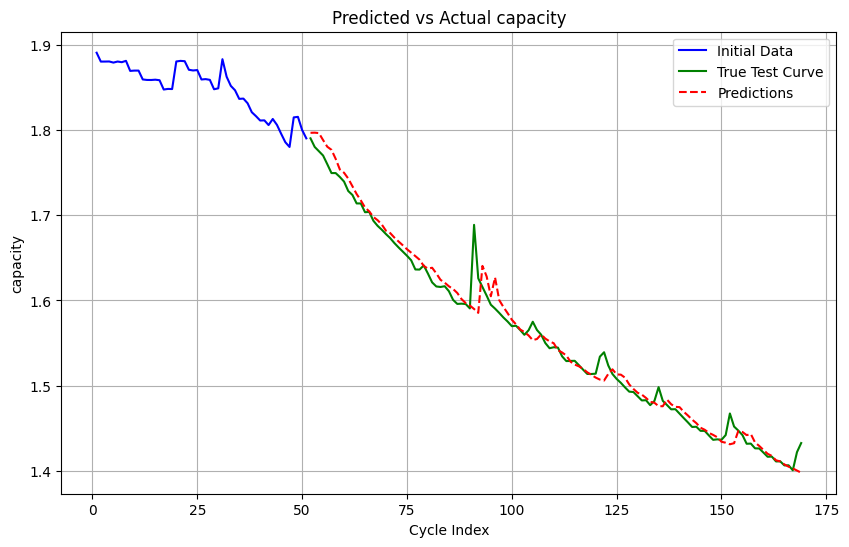

Epoch 1: Validation loss improved to 0.3687179982662201. Model saved!
Epoch 1/200, Train Loss: 0.3909050249136411, Val Loss: 0.3687179982662201
Epoch 2: Validation loss improved to 0.3639696165919304. Model saved!
Epoch 2/200, Train Loss: 0.36499348512062657, Val Loss: 0.3639696165919304
Epoch 3: Validation loss improved to 0.33576035499572754. Model saved!
Epoch 3/200, Train Loss: 0.34507304659256566, Val Loss: 0.33576035499572754
Epoch 4: Validation loss improved to 0.2803391143679619. Model saved!
Epoch 4/200, Train Loss: 0.29904475005773395, Val Loss: 0.2803391143679619
Epoch 5: Validation loss improved to 0.192758496850729. Model saved!
Epoch 5/200, Train Loss: 0.24747091761002174, Val Loss: 0.192758496850729
Epoch 6: Validation loss improved to 0.14157475531101227. Model saved!
Epoch 6/200, Train Loss: 0.1824908864039641, Val Loss: 0.14157475531101227
Epoch 7: Validation loss improved to 0.08652911521494389. Model saved!
Epoch 7/200, Train Loss: 0.1281189672075785, Val Loss: 0.08

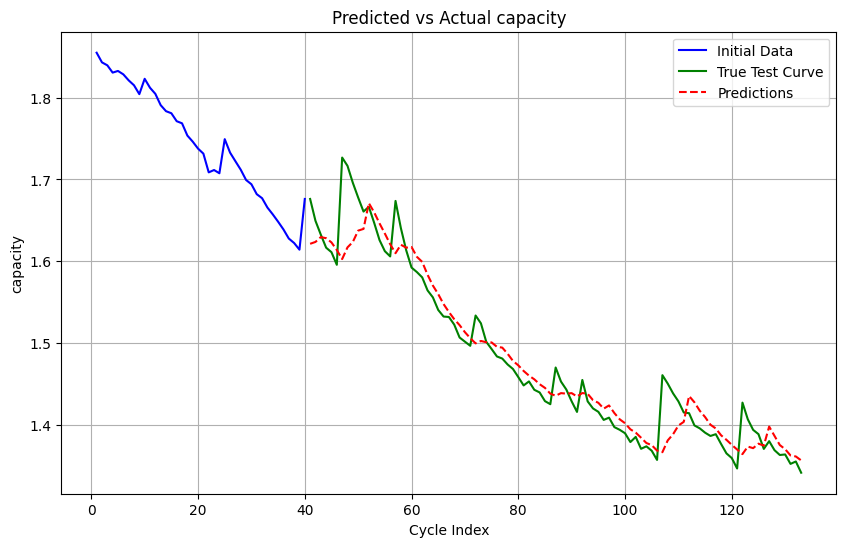

In [36]:

for i in range(4):
    model_1 = TCN_GRU_DNN_Model(window_size=5).to(device)
    optimizer = torch.optim.Adam(model_1.parameters(), lr=2e-4)
    criterion = torch.nn.MSELoss()
    EPOCHS = 200
    
    
    train_model(
        model=model_1,
        train_dataloader=NASA_train_dataloaders[i],
        val_dataloader=NASA_val_dataloaders[i],
        optimizer=optimizer,
        criterion=criterion,
        device=device,
        min_val=MIN,
        diff_val=DIFF,
        epochs=EPOCHS,
        unsqueeze_dim=1,
        log_interval=1,
        patience=50,
        save_path=ModelOutputConstants.NASA_OUTPUT_PATH.value / f'tcn_gru_dnn_{test_and_trains[i][0]}.pth'
    )
    
    model_1.load_state_dict(torch.load(ModelOutputConstants.NASA_OUTPUT_PATH.value / f'tcn_gru_dnn_{test_and_trains[i][0]}.pth'))
    model_1.to(device)

    metrics = evaluate_model(model_1, NASA_test_dataloaders[i], device, MIN, DIFF, 1)
    print(f'RMSE: {metrics['RMSE']}\nMAE: {metrics['MAE']}')

    plot_predictions(model_1, nasa_dfs, test_and_trains[i][0], generate_sliding_window_data, MIN, DIFF, device, 'capacity', 1, 30, 5)

## BiLSTM Attention Model

C:\Users\shubham mate\Desktop\Programming\Python\Battery RUL Project\venv\Lib\site-packages\torch\nn\modules\rnn.py:123: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.5 and num_layers=1
  warnings.warn(


Epoch 1: Validation loss improved to 0.5904905001322428. Model saved!
Epoch 1/100, Train Loss: 0.61563674112161, Val Loss: 0.5904905001322428
Epoch 2: Validation loss improved to 0.5131960312525431. Model saved!
Epoch 2/100, Train Loss: 0.5643011381228765, Val Loss: 0.5131960312525431
Epoch 3: Validation loss improved to 0.3590635359287262. Model saved!
Epoch 3/100, Train Loss: 0.4565329775214195, Val Loss: 0.3590635359287262
Epoch 4: Validation loss improved to 0.08452671021223068. Model saved!
Epoch 4/100, Train Loss: 0.24241496125857034, Val Loss: 0.08452671021223068
Epoch 5: Validation loss improved to 0.029801993320385616. Model saved!
Epoch 5/100, Train Loss: 0.02955891897242206, Val Loss: 0.029801993320385616
Epoch 6: Validation loss improved to 0.007757811496655147. Model saved!
Epoch 6/100, Train Loss: 0.009934082025817284, Val Loss: 0.007757811496655147
Epoch 7: Validation loss improved to 0.0017903163485849898. Model saved!
Epoch 7/100, Train Loss: 0.004168104244551311, Val 

C:\Users\shubham mate\AppData\Local\Temp\ipykernel_13228\3876086050.py:23: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model_2.load_state_dict(torch.load(ModelOutputConsta

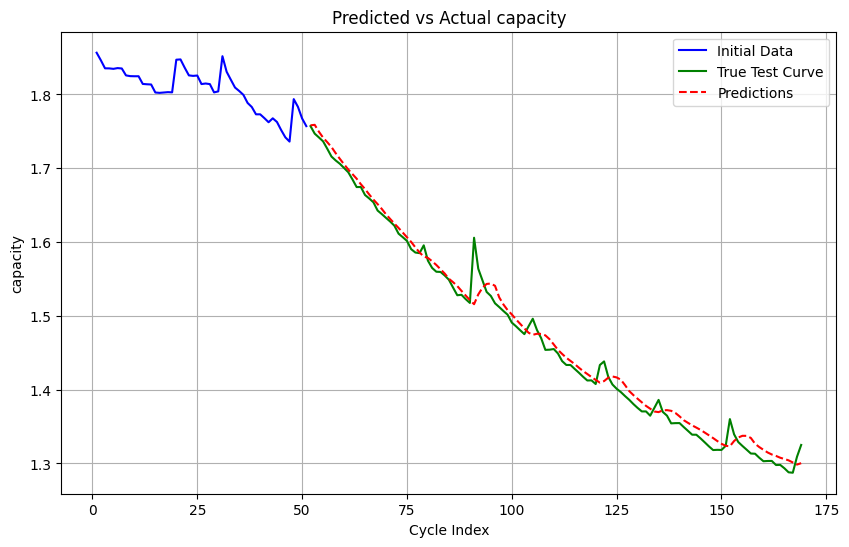

Epoch 1: Validation loss improved to 0.6178863445917765. Model saved!
Epoch 1/100, Train Loss: 0.6288746694723765, Val Loss: 0.6178863445917765
Epoch 2: Validation loss improved to 0.5860917369524637. Model saved!
Epoch 2/100, Train Loss: 0.6112952530384064, Val Loss: 0.5860917369524637
Epoch 3: Validation loss improved to 0.5268539985020956. Model saved!
Epoch 3/100, Train Loss: 0.5685786008834839, Val Loss: 0.5268539985020956
Epoch 4: Validation loss improved to 0.39013876517613727. Model saved!
Epoch 4/100, Train Loss: 0.4757016176978747, Val Loss: 0.39013876517613727
Epoch 5: Validation loss improved to 0.10631743570168813. Model saved!
Epoch 5/100, Train Loss: 0.2717070070405801, Val Loss: 0.10631743570168813
Epoch 6: Validation loss improved to 0.031174251809716225. Model saved!
Epoch 6/100, Train Loss: 0.03334334180302297, Val Loss: 0.031174251809716225
Epoch 7: Validation loss improved to 0.0034909407452990613. Model saved!
Epoch 7/100, Train Loss: 0.010439887613756582, Val Los

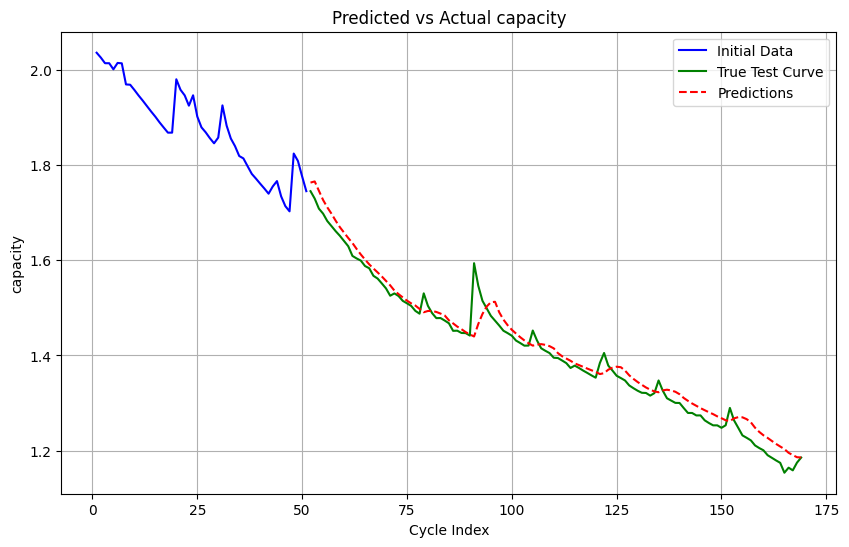

Epoch 1: Validation loss improved to 0.5888172189394633. Model saved!
Epoch 1/100, Train Loss: 0.6107952743768692, Val Loss: 0.5888172189394633
Epoch 2: Validation loss improved to 0.57595427831014. Model saved!
Epoch 2/100, Train Loss: 0.594766249259313, Val Loss: 0.57595427831014
Epoch 3: Validation loss improved to 0.5522065758705139. Model saved!
Epoch 3/100, Train Loss: 0.5787230034669241, Val Loss: 0.5522065758705139
Epoch 4: Validation loss improved to 0.5056097110112509. Model saved!
Epoch 4/100, Train Loss: 0.5417613312602043, Val Loss: 0.5056097110112509
Epoch 5: Validation loss improved to 0.4122437040011088. Model saved!
Epoch 5/100, Train Loss: 0.4784548158446948, Val Loss: 0.4122437040011088
Epoch 6: Validation loss improved to 0.20493681728839874. Model saved!
Epoch 6/100, Train Loss: 0.3343372357388337, Val Loss: 0.20493681728839874
Epoch 7: Validation loss improved to 0.0032698759653915963. Model saved!
Epoch 7/100, Train Loss: 0.08652260239371874, Val Loss: 0.00326987

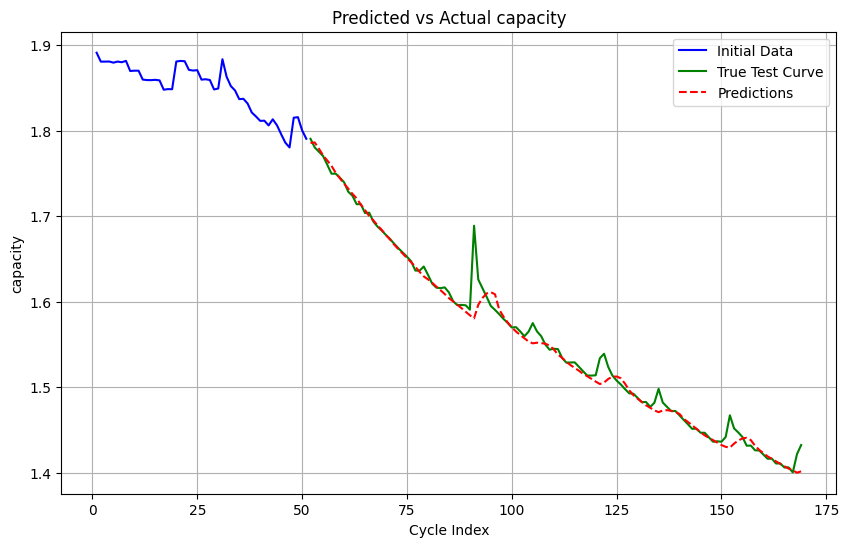

Epoch 1: Validation loss improved to 0.552548922598362. Model saved!
Epoch 1/100, Train Loss: 0.6262383231749902, Val Loss: 0.552548922598362
Epoch 2: Validation loss improved to 0.4613076150417328. Model saved!
Epoch 2/100, Train Loss: 0.5383270061933078, Val Loss: 0.4613076150417328
Epoch 3: Validation loss improved to 0.21482503414154053. Model saved!
Epoch 3/100, Train Loss: 0.35578760275473964, Val Loss: 0.21482503414154053
Epoch 4: Validation loss improved to 0.013574542943388224. Model saved!
Epoch 4/100, Train Loss: 0.07635196138065882, Val Loss: 0.013574542943388224
Epoch 5: Validation loss improved to 0.002809438679832965. Model saved!
Epoch 5/100, Train Loss: 0.016085473475798678, Val Loss: 0.002809438679832965
Epoch 6: Validation loss improved to 0.0017371943104080856. Model saved!
Epoch 6/100, Train Loss: 0.005267471433258974, Val Loss: 0.0017371943104080856
Epoch 7: Validation loss improved to 0.0016986392147373408. Model saved!
Epoch 7/100, Train Loss: 0.0020767758743694

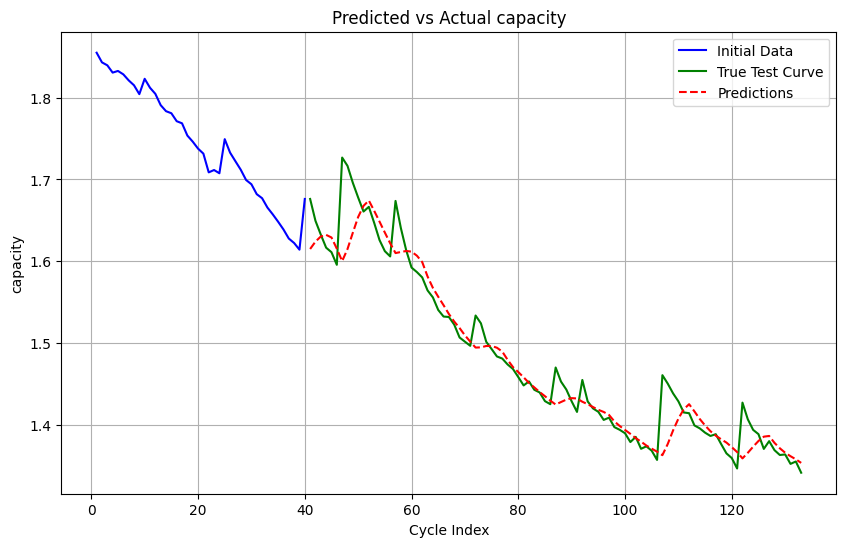

In [34]:

for i in range(4):
    model_2 = BiLSTM_Attention(128).to(device)
    optimizer = torch.optim.Adam(model_2.parameters(), lr=1e-4)
    criterion = torch.nn.MSELoss()
    EPOCHS = 100
    
    train_model(
        model=model_2,
        train_dataloader=NASA_train_dataloaders[i],
        val_dataloader=NASA_val_dataloaders[i],
        optimizer=optimizer,
        criterion=criterion,
        device=device,
        min_val=MIN,
        diff_val=DIFF,
        epochs=EPOCHS,
        unsqueeze_dim=-1,
        log_interval=1,
        patience=10,
        save_path=ModelOutputConstants.NASA_OUTPUT_PATH.value / f'attn_bilstm_{test_and_trains[i][0]}.pth'
    )
    
    model_2.load_state_dict(torch.load(ModelOutputConstants.NASA_OUTPUT_PATH.value / f'attn_bilstm_{test_and_trains[i][0]}.pth'))
    model_2.to(device)

    metrics = evaluate_model(model_2, NASA_test_dataloaders[i], device, MIN, DIFF, -1)
    print(f'RMSE: {metrics['RMSE']}\nMAE: {metrics['MAE']}')

    plot_predictions(model_2, nasa_dfs, test_and_trains[i][0], generate_sliding_window_data, MIN, DIFF, device, 'capacity', -1, 30, 5)

## ABC (Artificial Bee Colony) BiGRU Model

In [20]:
bounds = np.array([
    [16, 128],    # Hidden size
    [1e-4, 1e-2], # Learning rate
    [0.1, 0.5]    # Dropout
])

# Run the ABC algorithm with the provided dataloaders
best_params, best_mse = abc_algorithm(bounds, NASA_train_dataloaders[0], NASA_test_dataloaders[0], device, n_solutions=10, max_iters=20, window_size=5)
print("Best Parameters:", best_params)
print("Best MSE:", best_mse)

Iteration 1/20, Best Fitness (MSE): 0.011450957041233778
Iteration 2/20, Best Fitness (MSE): 0.011450957041233778
Iteration 3/20, Best Fitness (MSE): 0.011450957041233778
Iteration 4/20, Best Fitness (MSE): 0.011450957041233778
Iteration 5/20, Best Fitness (MSE): 0.010414043596635262
Iteration 6/20, Best Fitness (MSE): 0.010414043596635262
Iteration 7/20, Best Fitness (MSE): 0.00877323878618578
Iteration 8/20, Best Fitness (MSE): 0.00877323878618578
Iteration 9/20, Best Fitness (MSE): 0.00877323878618578
Iteration 10/20, Best Fitness (MSE): 0.00877323878618578
Iteration 11/20, Best Fitness (MSE): 0.00877323878618578
Iteration 12/20, Best Fitness (MSE): 0.00877323878618578
Iteration 13/20, Best Fitness (MSE): 0.00877323878618578
Iteration 14/20, Best Fitness (MSE): 0.005713434948120266
Iteration 15/20, Best Fitness (MSE): 0.005713434948120266
Iteration 16/20, Best Fitness (MSE): 0.004384957564373811
Iteration 17/20, Best Fitness (MSE): 0.004384957564373811
Iteration 18/20, Best Fitness 

Epoch 1: Validation loss improved to 0.035136569291353226. Model saved!
Epoch 1/200, Train Loss: 0.0408195072474579, Val Loss: 0.035136569291353226
Epoch 2: Validation loss improved to 0.034803523371617. Model saved!
Epoch 2/200, Train Loss: 0.039405515107015766, Val Loss: 0.034803523371617
Epoch 3: Validation loss improved to 0.03377098962664604. Model saved!
Epoch 3/200, Train Loss: 0.039856471586972475, Val Loss: 0.03377098962664604
Epoch 4: Validation loss improved to 0.03288463441034158. Model saved!
Epoch 4/200, Train Loss: 0.0376506724084417, Val Loss: 0.03288463441034158
Epoch 5: Validation loss improved to 0.03214163767794768. Model saved!
Epoch 5/200, Train Loss: 0.038272642685721316, Val Loss: 0.03214163767794768
Epoch 6: Validation loss improved to 0.03205464345713457. Model saved!
Epoch 6/200, Train Loss: 0.03717131447046995, Val Loss: 0.03205464345713457
Epoch 7: Validation loss improved to 0.03147563338279724. Model saved!
Epoch 7/200, Train Loss: 0.03571213207518061, Va

C:\Users\shubham mate\AppData\Local\Temp\ipykernel_13228\1578749955.py:23: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model_3.load_state_dict(torch.load(ModelOutputConsta

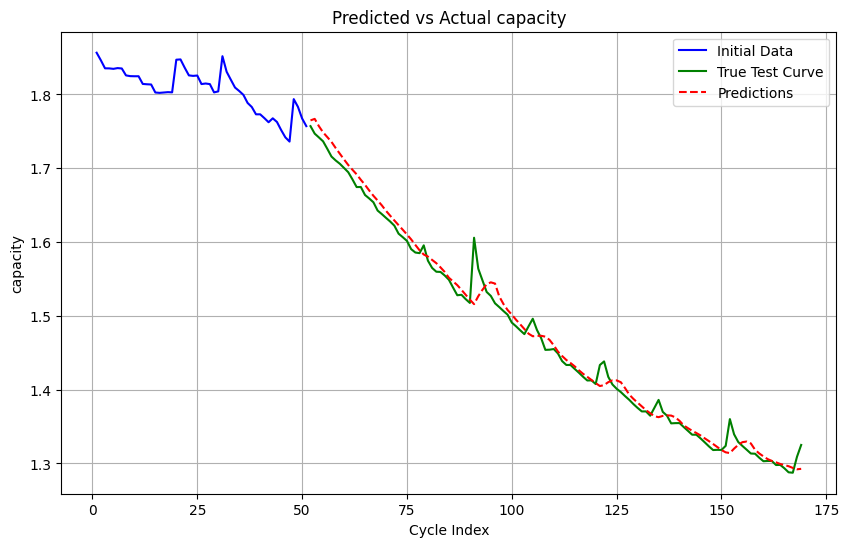

Epoch 1: Validation loss improved to 0.06215086579322815. Model saved!
Epoch 1/200, Train Loss: 0.06801130839933951, Val Loss: 0.06215086579322815
Epoch 2: Validation loss improved to 0.05823818345864614. Model saved!
Epoch 2/200, Train Loss: 0.06279910355806351, Val Loss: 0.05823818345864614
Epoch 3: Validation loss improved to 0.05586053431034088. Model saved!
Epoch 3/200, Train Loss: 0.062212975385288395, Val Loss: 0.05586053431034088
Epoch 4: Validation loss improved to 0.0535799041390419. Model saved!
Epoch 4/200, Train Loss: 0.05953739210963249, Val Loss: 0.0535799041390419
Epoch 5: Validation loss improved to 0.051385520646969475. Model saved!
Epoch 5/200, Train Loss: 0.05750788344691197, Val Loss: 0.051385520646969475
Epoch 6: Validation loss improved to 0.04871409945189953. Model saved!
Epoch 6/200, Train Loss: 0.055912122751275696, Val Loss: 0.04871409945189953
Epoch 7: Validation loss improved to 0.04735782245794932. Model saved!
Epoch 7/200, Train Loss: 0.05339840737481912,

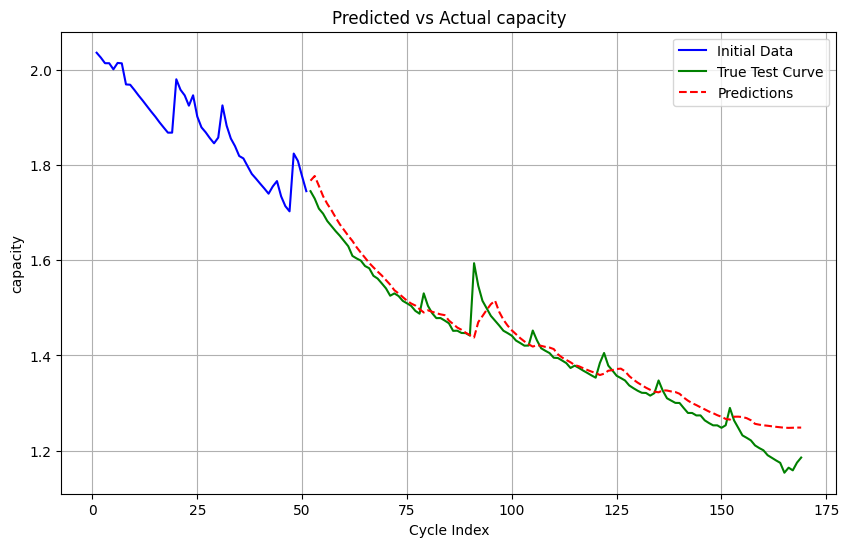

Epoch 1: Validation loss improved to 0.8640680511792501. Model saved!
Epoch 1/200, Train Loss: 0.8845821470022202, Val Loss: 0.8640680511792501
Epoch 2: Validation loss improved to 0.8580693999926249. Model saved!
Epoch 2/200, Train Loss: 0.8896950980027517, Val Loss: 0.8580693999926249
Epoch 3: Validation loss improved to 0.847022533416748. Model saved!
Epoch 3/200, Train Loss: 0.8810841043790182, Val Loss: 0.847022533416748
Epoch 4: Validation loss improved to 0.8430555065472921. Model saved!
Epoch 4/200, Train Loss: 0.8686158160368601, Val Loss: 0.8430555065472921
Epoch 5: Validation loss improved to 0.8375003933906555. Model saved!
Epoch 5/200, Train Loss: 0.8680743426084518, Val Loss: 0.8375003933906555
Epoch 6: Validation loss improved to 0.8331845800081888. Model saved!
Epoch 6/200, Train Loss: 0.8652646938959757, Val Loss: 0.8331845800081888
Epoch 7: Validation loss improved to 0.8268478115399679. Model saved!
Epoch 7/200, Train Loss: 0.8613474319378535, Val Loss: 0.82684781153

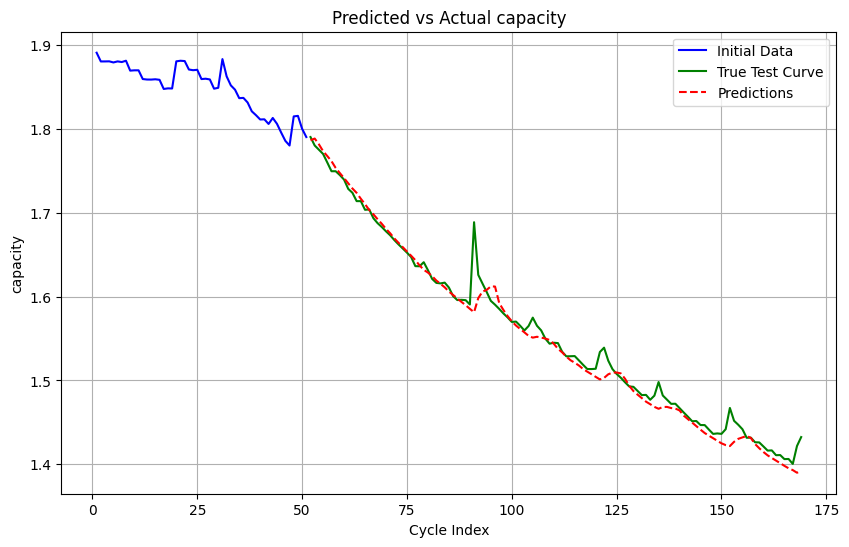

Epoch 1: Validation loss improved to 0.6379008591175079. Model saved!
Epoch 1/200, Train Loss: 0.6322386173101572, Val Loss: 0.6379008591175079
Epoch 2: Validation loss improved to 0.5651611462235451. Model saved!
Epoch 2/200, Train Loss: 0.6057449120741624, Val Loss: 0.5651611462235451
Epoch 3: Validation loss improved to 0.5087451934814453. Model saved!
Epoch 3/200, Train Loss: 0.6120697351602408, Val Loss: 0.5087451934814453
Epoch 4: No improvement. (1/20)
Epoch 4/200, Train Loss: 0.5962439958865826, Val Loss: 0.5145670473575592
Epoch 5: Validation loss improved to 0.4996960461139679. Model saved!
Epoch 5/200, Train Loss: 0.5661682624083298, Val Loss: 0.4996960461139679
Epoch 6: Validation loss improved to 0.4865138605237007. Model saved!
Epoch 6/200, Train Loss: 0.5413096317878137, Val Loss: 0.4865138605237007
Epoch 7: No improvement. (1/20)
Epoch 7/200, Train Loss: 0.5256048418008364, Val Loss: 0.5555131286382675
Epoch 8: Validation loss improved to 0.4818095937371254. Model saved

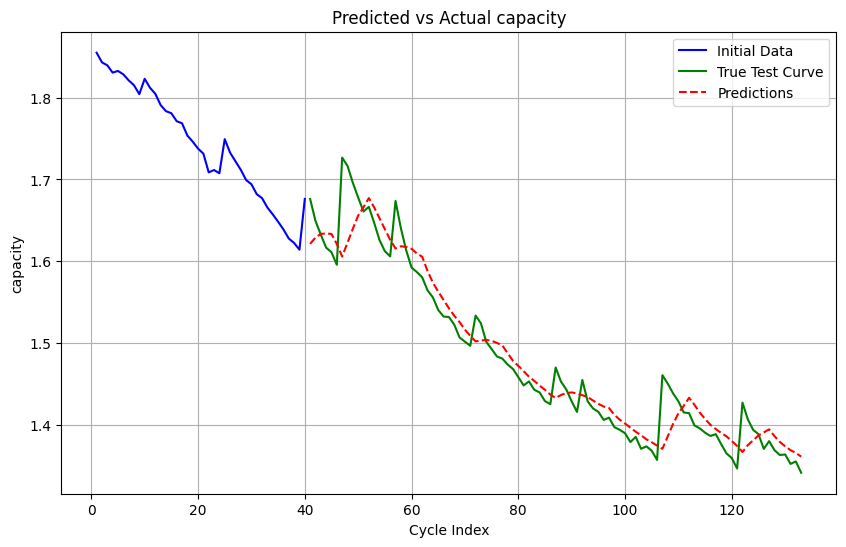

In [24]:

for i in range(4):
    model_3 = BiGRUModel(input_size=5, hidden_size=int(round(best_params[0])), dropout=best_params[2]).to(device)
    optimizer = torch.optim.Adam(model_3.parameters(), lr=1e-4)
    criterion = torch.nn.MSELoss()
    EPOCHS = 200
    
    train_model(
        model=model_3,
        train_dataloader=NASA_train_dataloaders[i],
        val_dataloader=NASA_val_dataloaders[i],
        optimizer=optimizer,
        criterion=criterion,
        device=device,
        min_val=MIN,
        diff_val=DIFF,
        epochs=EPOCHS,
        unsqueeze_dim=1,
        log_interval=1,
        patience=20,
        save_path=ModelOutputConstants.NASA_OUTPUT_PATH.value / f'abc_bigru_{test_and_trains[i][0]}.pth'
    )
    
    model_3.load_state_dict(torch.load(ModelOutputConstants.NASA_OUTPUT_PATH.value / f'abc_bigru_{test_and_trains[i][0]}.pth'))
    model_3.to(device)

    metrics = evaluate_model(model_3, NASA_test_dataloaders[i], device, MIN, DIFF, 1)
    print(f'RMSE: {metrics['RMSE']}\nMAE: {metrics['MAE']}')

    plot_predictions(model_3, nasa_dfs, test_and_trains[i][0], generate_sliding_window_data, MIN, DIFF, device, 'capacity', 1, 30, 5)

## CNN - DBLSTM Model

Epoch 1: Validation loss improved to 0.44021596511205036. Model saved!
Epoch 1/200, Train Loss: 0.4669952392578125, Val Loss: 0.44021596511205036
Epoch 2: Validation loss improved to 0.4066307048002879. Model saved!
Epoch 2/200, Train Loss: 0.4310321460167567, Val Loss: 0.4066307048002879
Epoch 3: Validation loss improved to 0.3341528574625651. Model saved!
Epoch 3/200, Train Loss: 0.3780365784962972, Val Loss: 0.3341528574625651
Epoch 4: Validation loss improved to 0.11139209568500519. Model saved!
Epoch 4/200, Train Loss: 0.23631864041090012, Val Loss: 0.11139209568500519
Epoch 5: Validation loss improved to 0.026048216968774796. Model saved!
Epoch 5/200, Train Loss: 0.04269761871546507, Val Loss: 0.026048216968774796
Epoch 6: Validation loss improved to 0.007084956392645836. Model saved!
Epoch 6/200, Train Loss: 0.019334552188714344, Val Loss: 0.007084956392645836
Epoch 7: Validation loss improved to 0.004876629604647557. Model saved!
Epoch 7/200, Train Loss: 0.008770678153571984, V

C:\Users\shubham mate\AppData\Local\Temp\ipykernel_13228\3903676300.py:24: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model_4.load_state_dict(torch.load(ModelOutputConsta

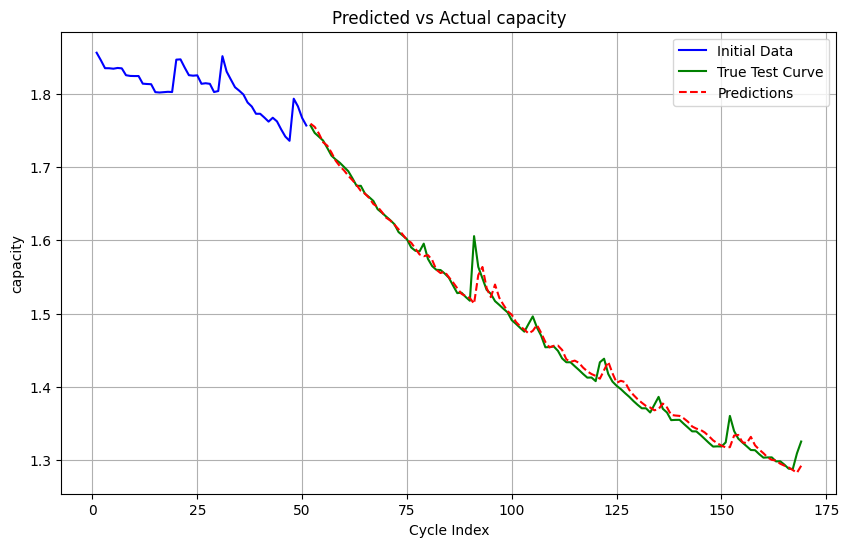

Epoch 1: Validation loss improved to 0.7125174204508463. Model saved!
Epoch 1/200, Train Loss: 0.7321029404799143, Val Loss: 0.7125174204508463
Epoch 2: Validation loss improved to 0.6914105614026388. Model saved!
Epoch 2/200, Train Loss: 0.7181156178315481, Val Loss: 0.6914105614026388
Epoch 3: Validation loss improved to 0.6331647435824076. Model saved!
Epoch 3/200, Train Loss: 0.6757904142141342, Val Loss: 0.6331647435824076
Epoch 4: Validation loss improved to 0.3349926273028056. Model saved!
Epoch 4/200, Train Loss: 0.506816565990448, Val Loss: 0.3349926273028056
Epoch 5: Validation loss improved to 0.020607807983954746. Model saved!
Epoch 5/200, Train Loss: 0.1410218597544978, Val Loss: 0.020607807983954746
Epoch 6: No improvement. (1/30)
Epoch 6/200, Train Loss: 0.032642870054890714, Val Loss: 0.029960193981726963
Epoch 7: Validation loss improved to 0.012114088361461958. Model saved!
Epoch 7/200, Train Loss: 0.01848484909472366, Val Loss: 0.012114088361461958
Epoch 8: Validatio

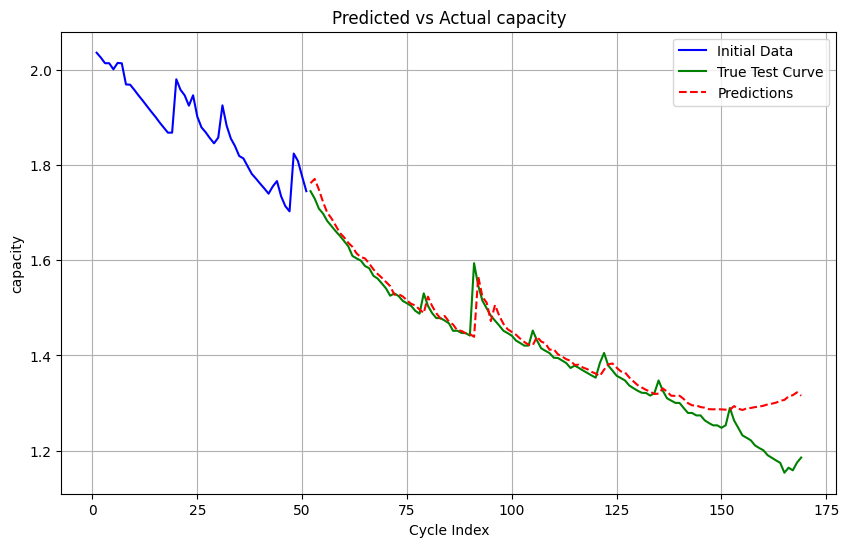

Epoch 1: Validation loss improved to 0.30869853496551514. Model saved!
Epoch 1/200, Train Loss: 0.34555236250162125, Val Loss: 0.30869853496551514
Epoch 2: Validation loss improved to 0.2790602544943492. Model saved!
Epoch 2/200, Train Loss: 0.3129795988400777, Val Loss: 0.2790602544943492
Epoch 3: Validation loss improved to 0.22619788348674774. Model saved!
Epoch 3/200, Train Loss: 0.26687073955933255, Val Loss: 0.22619788348674774
Epoch 4: Validation loss improved to 0.04390854140122732. Model saved!
Epoch 4/200, Train Loss: 0.13967021399488053, Val Loss: 0.04390854140122732
Epoch 5: Validation loss improved to 0.018704164152344067. Model saved!
Epoch 5/200, Train Loss: 0.021984501198555034, Val Loss: 0.018704164152344067
Epoch 6: Validation loss improved to 0.004496751275534431. Model saved!
Epoch 6/200, Train Loss: 0.0068122040150531875, Val Loss: 0.004496751275534431
Epoch 7: Validation loss improved to 0.0026335070142522454. Model saved!
Epoch 7/200, Train Loss: 0.00614485049542

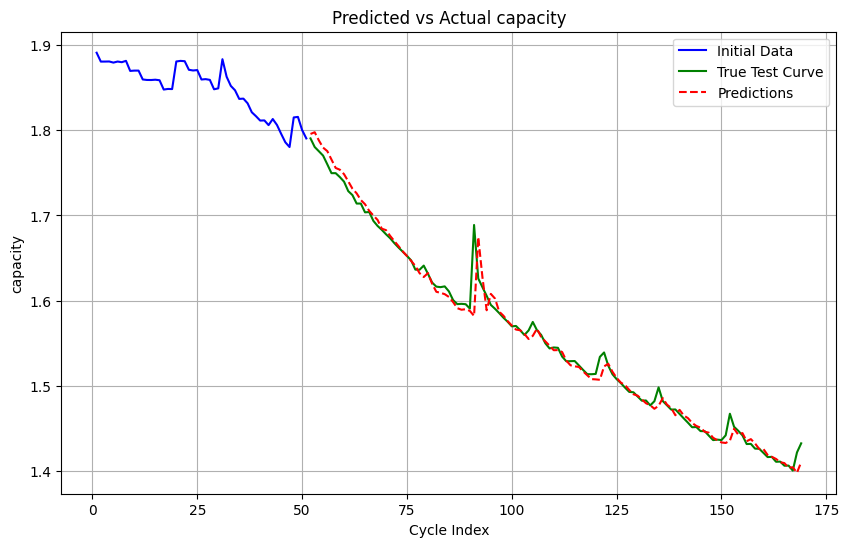

Epoch 1: Validation loss improved to 0.5293441638350487. Model saved!
Epoch 1/200, Train Loss: 0.5675036998895499, Val Loss: 0.5293441638350487
Epoch 2: Validation loss improved to 0.42948950082063675. Model saved!
Epoch 2/200, Train Loss: 0.5321459770202637, Val Loss: 0.42948950082063675
Epoch 3: Validation loss improved to 0.4010613337159157. Model saved!
Epoch 3/200, Train Loss: 0.46223458418479335, Val Loss: 0.4010613337159157
Epoch 4: Validation loss improved to 0.15343903843313456. Model saved!
Epoch 4/200, Train Loss: 0.31596500827715945, Val Loss: 0.15343903843313456
Epoch 5: Validation loss improved to 0.031230159103870392. Model saved!
Epoch 5/200, Train Loss: 0.09436758493001644, Val Loss: 0.031230159103870392
Epoch 6: No improvement. (1/30)
Epoch 6/200, Train Loss: 0.03487175316191637, Val Loss: 0.03769338130950928
Epoch 7: Validation loss improved to 0.01228777039796114. Model saved!
Epoch 7/200, Train Loss: 0.018615297185113795, Val Loss: 0.01228777039796114
Epoch 8: Vali

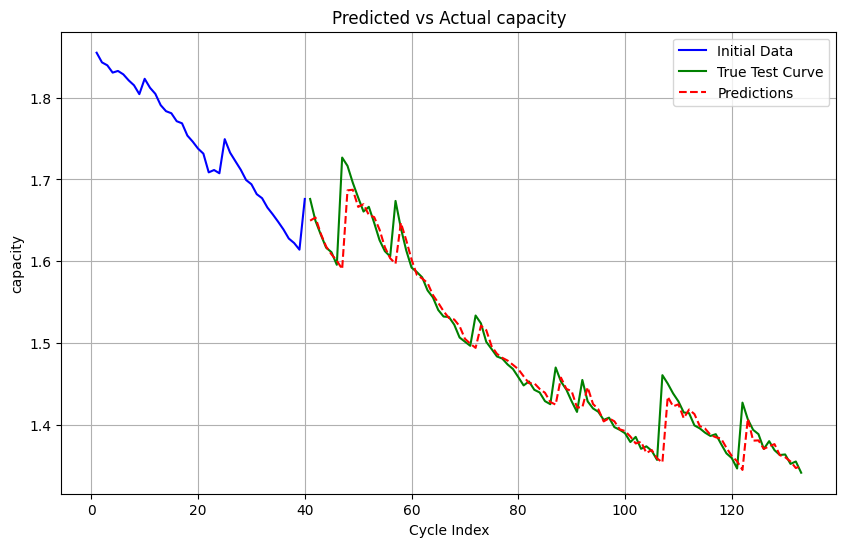

In [28]:

for i in range(4):
    model_4 = CNN_DBLSTM_Model([24, 48, 72], 128, 4).to(device)
    optimizer = torch.optim.Adam(model_4.parameters(), lr=1e-4)
    criterion = torch.nn.MSELoss()
    EPOCHS = 200
    
    
    train_model(
        model=model_4,
        train_dataloader=NASA_train_dataloaders[i],
        val_dataloader=NASA_val_dataloaders[i],
        optimizer=optimizer,
        criterion=criterion,
        device=device,
        min_val=MIN,
        diff_val=DIFF,
        epochs=EPOCHS,
        unsqueeze_dim=1,
        log_interval=1,
        patience=30,
        save_path=ModelOutputConstants.NASA_OUTPUT_PATH.value / f'cnn_dblstm_{test_and_trains[i][0]}.pth'
    )
    
    model_4.load_state_dict(torch.load(ModelOutputConstants.NASA_OUTPUT_PATH.value / f'cnn_dblstm_{test_and_trains[i][0]}.pth'))
    model_4.to(device)

    metrics = evaluate_model(model_4, NASA_test_dataloaders[i], device, MIN, DIFF, 1)
    print(f'RMSE: {metrics['RMSE']}\nMAE: {metrics['MAE']}')

    plot_predictions(model_4, nasa_dfs, test_and_trains[i][0], generate_sliding_window_data, MIN, DIFF, device, 'capacity', 1, 30, 5)

## CNN - ASTLSTM

Epoch 1: Validation loss improved to 0.3250129024187724. Model saved!
Epoch 1/200, Train Loss: 0.3535235946377118, Val Loss: 0.3250129024187724
Epoch 2: Validation loss improved to 0.2913090984026591. Model saved!
Epoch 2/200, Train Loss: 0.316660047819217, Val Loss: 0.2913090984026591
Epoch 3: Validation loss improved to 0.2655376394589742. Model saved!
Epoch 3/200, Train Loss: 0.29067030052344006, Val Loss: 0.2655376394589742
Epoch 4: Validation loss improved to 0.24527334670225778. Model saved!
Epoch 4/200, Train Loss: 0.2630024813115597, Val Loss: 0.24527334670225778
Epoch 5: Validation loss improved to 0.22655256589253744. Model saved!
Epoch 5/200, Train Loss: 0.24828653782606125, Val Loss: 0.22655256589253744
Epoch 6: Validation loss improved to 0.20851613581180573. Model saved!
Epoch 6/200, Train Loss: 0.22630745048324266, Val Loss: 0.20851613581180573
Epoch 7: Validation loss improved to 0.19026239216327667. Model saved!
Epoch 7/200, Train Loss: 0.20391986519098282, Val Loss: 0

C:\Users\shubham mate\AppData\Local\Temp\ipykernel_13228\254619299.py:24: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model_5.load_state_dict(torch.load(ModelOutputConstan

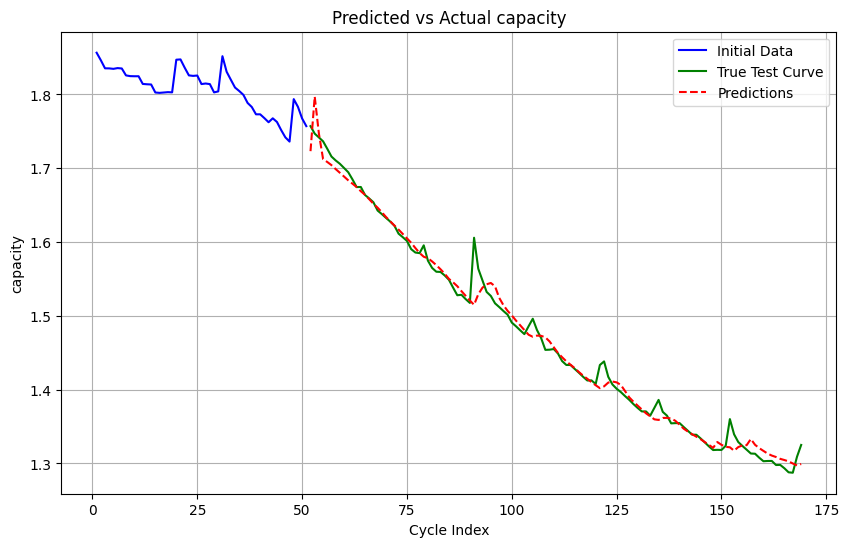

Epoch 1: Validation loss improved to 0.16672316193580627. Model saved!
Epoch 1/200, Train Loss: 0.18904267127315202, Val Loss: 0.16672316193580627
Epoch 2: Validation loss improved to 0.1478995531797409. Model saved!
Epoch 2/200, Train Loss: 0.16508587325612703, Val Loss: 0.1478995531797409
Epoch 3: Validation loss improved to 0.13129525383313498. Model saved!
Epoch 3/200, Train Loss: 0.14924747310578823, Val Loss: 0.13129525383313498
Epoch 4: Validation loss improved to 0.11723876496156056. Model saved!
Epoch 4/200, Train Loss: 0.13249426831801733, Val Loss: 0.11723876496156056
Epoch 5: Validation loss improved to 0.10321332762638728. Model saved!
Epoch 5/200, Train Loss: 0.11418751006325085, Val Loss: 0.10321332762638728
Epoch 6: Validation loss improved to 0.09256050984064738. Model saved!
Epoch 6/200, Train Loss: 0.10347013734281063, Val Loss: 0.09256050984064738
Epoch 7: Validation loss improved to 0.08026061455408733. Model saved!
Epoch 7/200, Train Loss: 0.08955774021645387, Val

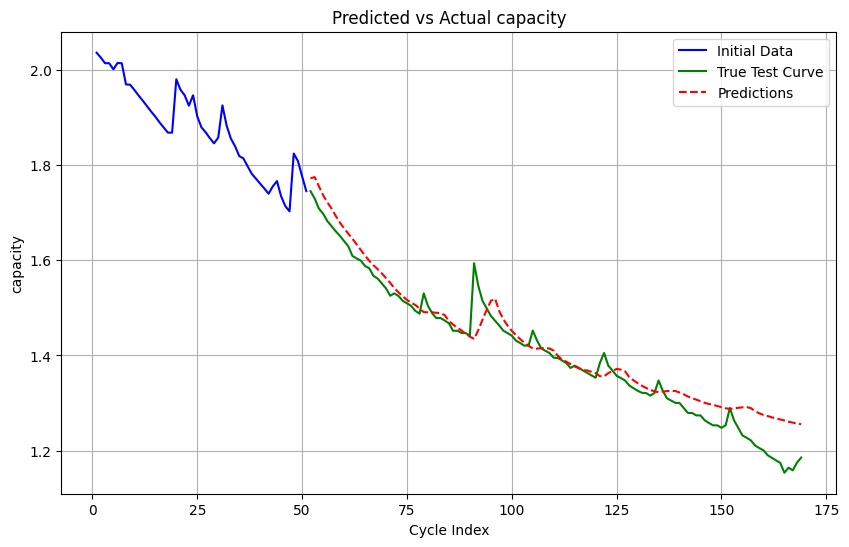

Epoch 1: Validation loss improved to 0.281831294298172. Model saved!
Epoch 1/200, Train Loss: 0.3265400106708209, Val Loss: 0.281831294298172
Epoch 2: Validation loss improved to 0.23948784669240317. Model saved!
Epoch 2/200, Train Loss: 0.2768280195693175, Val Loss: 0.23948784669240317
Epoch 3: Validation loss improved to 0.20500577986240387. Model saved!
Epoch 3/200, Train Loss: 0.23930498957633972, Val Loss: 0.20500577986240387
Epoch 4: Validation loss improved to 0.17337151368459067. Model saved!
Epoch 4/200, Train Loss: 0.20734343429406485, Val Loss: 0.17337151368459067
Epoch 5: Validation loss improved to 0.15089222292105356. Model saved!
Epoch 5/200, Train Loss: 0.17927072942256927, Val Loss: 0.15089222292105356
Epoch 6: Validation loss improved to 0.12790139764547348. Model saved!
Epoch 6/200, Train Loss: 0.15331660211086273, Val Loss: 0.12790139764547348
Epoch 7: Validation loss improved to 0.10820748656988144. Model saved!
Epoch 7/200, Train Loss: 0.1347447633743286, Val Loss

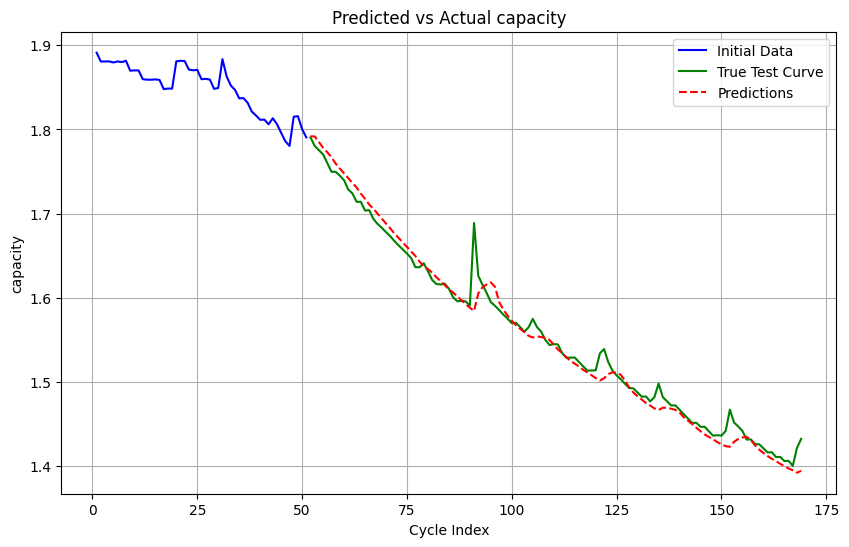

Epoch 1: Validation loss improved to 0.46124185621738434. Model saved!
Epoch 1/200, Train Loss: 0.48578505103404707, Val Loss: 0.46124185621738434
Epoch 2: Validation loss improved to 0.4573832303285599. Model saved!
Epoch 2/200, Train Loss: 0.44914750640208906, Val Loss: 0.4573832303285599
Epoch 3: Validation loss improved to 0.3259006142616272. Model saved!
Epoch 3/200, Train Loss: 0.39923936128616333, Val Loss: 0.3259006142616272
Epoch 4: Validation loss improved to 0.31259631365537643. Model saved!
Epoch 4/200, Train Loss: 0.3628444579931406, Val Loss: 0.31259631365537643
Epoch 5: Validation loss improved to 0.27405474334955215. Model saved!
Epoch 5/200, Train Loss: 0.3202153008717757, Val Loss: 0.27405474334955215
Epoch 6: No improvement. (1/30)
Epoch 6/200, Train Loss: 0.29858843638346744, Val Loss: 0.306301012635231
Epoch 7: Validation loss improved to 0.1977176070213318. Model saved!
Epoch 7/200, Train Loss: 0.27345869976740617, Val Loss: 0.1977176070213318
Epoch 8: No improvem

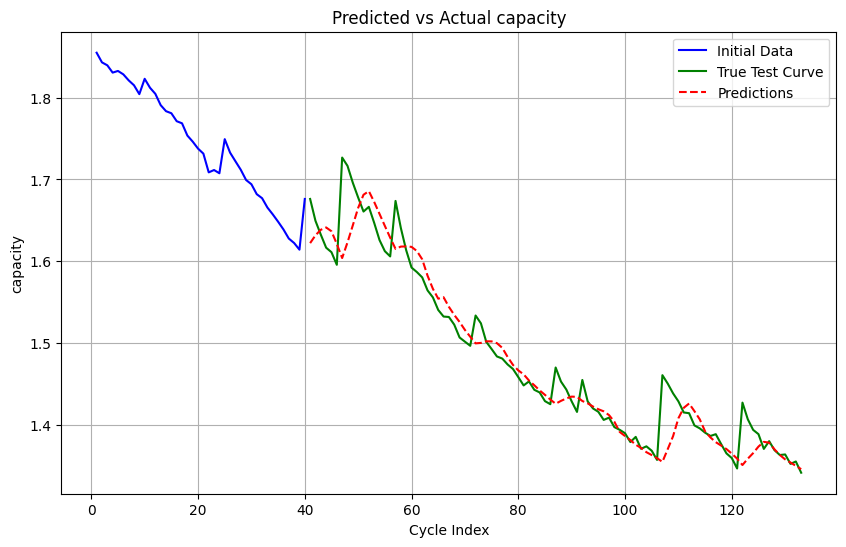

In [31]:

for i in range(4):
    model_5 = CNN_ASTLSTM(46, [24, 28]).to(device)
    optimizer = torch.optim.Adam(model_5.parameters(), lr=1e-4)
    criterion = torch.nn.MSELoss()
    EPOCHS = 200
    
    
    train_model(
        model=model_5,
        train_dataloader=NASA_train_dataloaders[i],
        val_dataloader=NASA_val_dataloaders[i],
        optimizer=optimizer,
        criterion=criterion,
        device=device,
        min_val=MIN,
        diff_val=DIFF,
        epochs=EPOCHS,
        unsqueeze_dim=1,
        log_interval=1,
        patience=30,
        save_path=ModelOutputConstants.NASA_OUTPUT_PATH.value / f'cnn_astlstm_{test_and_trains[i][0]}.pth'
    )
    
    model_5.load_state_dict(torch.load(ModelOutputConstants.NASA_OUTPUT_PATH.value / f'cnn_astlstm_{test_and_trains[i][0]}.pth'))
    model_5.to(device)

    metrics = evaluate_model(model_5, NASA_test_dataloaders[i], device, MIN, DIFF, 1)
    print(f'RMSE: {metrics['RMSE']}\nMAE: {metrics['MAE']}')

    plot_predictions(model_5, nasa_dfs, test_and_trains[i][0], generate_sliding_window_data, MIN, DIFF, device, 'capacity', 1, 30, 5)